# Character Language Modelling
- Deadline: 29-Oct-2025 (11:59 PM)
- Submission: https://forms.gle/CnEC9mBY5wufJQSVA

# **Assignment Instructions:**

1. Read all Instructions carefully provided for each question before beginning your work.

2. Analyze each question thoroughly and document your result, analysis, and solutions within the Google Colab notebook itself.


3. This is an individual assignment. Your work should be original. Copying from peers or online sources is strictly prohibited.

4. The use of AI tools like ChatGPT, Copilot, Gemini, LLMs or any other automated code generation tools for writing code is strictly forbidden. We will be taking your Viva for evaluating the assignment.

5. Clearly document your code with comments and explanations so that it is easy to understand your approach and thought process. It is ok to take help from some external tutorial; however cite it in your documenation otherwise it will be considered plagiarism.

6. Follow the submission guidelines strictly. Make sure your notebook is well-organized and includes all necessary code, explanations, and outputs.

7. **Once you submit your assignment, a viva will be taken to evalute you.
For the assignment submission you will have to download this colab notebook as .ipynb file, zip it and submit it via this form:https://forms.gle/CnEC9mBY5wufJQSVA**
8. The name of the zip file should follow this format: "CS779-A5-[Firstname]-[Lastname]-[Rollno].zip", where [Firstname]-[Lastname]-[Rollno] is same as your discord username. If you fail to do this, then we will not able to recover your assignment from pool of assignments as the process is automated.

9. The above form will close at the above mentioned deadline and no further solutions will be accepted either by email or by any other means.

10. If you have any doubt or get stuck in any problem, consult  TA's over Discord. It's better to take help of TAs than cheating.



#**Enter your details below:**

Full Name: Naman Sethi

Roll No:  220688

Email: namansethi22@iitk.ac.in




# FOLDER STRUCTURE
```md
CS779_A5_Submission/
├─ notebooks/
│  └─ CS779_A5_Answers_Template.ipynb
│
├─ experiments/
│  ├─ results/
│  │  ├─ q1/
│  │  │  ├─ meta.json
│  │  │  └─ log_pretrain.csv              
│  │  ├─ q2/
│  │  │  └─ metrics.csv                   
│  │  │   
│  │  └─ q3d/
│  │     ├─ metrics.csv       
│  │     ├─ history.csv             
│  │     └─ roc_points.csv                
│  └─ figures/
│     ├─ q2/
│     │  ├─ train_loss_curve.png          
│     │  └─ cer_curve.png                 
│     └─ q3d/
│        ├─ acc_curve.png                 
│        ├─ loss_curve.png                
│        └─ roc_curve.png                 
│
└─ README.md
```

# Character-level Causal Language Model – Pretraining (Fully Explained) [Implementation - 200 Marks]

Language models are the engines behind today’s AI text generators. Popular models including ChatGPT, Llama etc. generate text by predicting the next-token (I hope you remember tokens from previous assignments). Instead of predicting words/tokens, character-level language models learn language at the tiniest possible unit — the character. This means that, given just a few starting letters, the model can generate entire words and sentences from scratch. Think of it as teaching a computer how to spell and write creatively at the same time.

Let’s make this idea concrete. Suppose you feed the model an initial string like:

```text
The sun se
```

A word-level model might struggle if “sets” or “serpent” are rare words in its training data. But a character-level model can continue letter by letter: t, s, e, … composing “sets beyond the hills.” It does this by learning statistical patterns — which characters tend to follow which others — and by remembering longer structures, such as how sentences often end with a period or new line.

### **Why Character-Level Models Matter**

Character-level models are simple yet powerful:
- They don’t need tokenizers — just a list of characters.
- They’re great for low-resource languages or for handling creative or noisy text (like social media posts or code).
- They form the foundation for more advanced neural architectures, like decoder-only transformers used in models such as GPT.

### **Understanding the Decoder-Only Transformer**

A decoder-only transformer is the architecture at the heart of models like GPT. It builds upon three main concepts:
- Causal multi-head self-attention: Each token (or character) only attends to earlier ones, preserving the left-to-right flow of language. Additionally, multi-head attention ensures that multiple qualities of the text are attended to.
- Feed-forward layers: These refine each token’s hidden representation.
- Residual and normalization layers: They help stabilize training and maintain information across layers.

Multiple such blocks are stacked to form the full model. The output from the final layer predicts the next character using a classification head.

Visualizing this helps a lot. Here are some student-friendly visual guides to explore:
- [Decoder-only Transformer Diagram (Substack)](https://cameronrwolfe.substack.com/p/decoder-only-transformers-the-workhorse) — a clear depiction of self-attention and block stacking.
- [Transformer Architecture Illustrated (Hugging Face LLM Course)](https://huggingface.co/learn/llm-course/en/chapter1/6) — introduction with intuitive sequence flow.
- [Poloclub Transformer Explainer (Interactive)](https://poloclub.github.io/transformer-explainer/) — try out a live GPT-2 visualization to see predictions evolve in real time.

### **Bringing It All Together**

In this assignment, you’ll:

- Build your own character-level model.
- Train it to generate text character by character.
- Finetune it to:
  - Correct spellings in input text.
  - Find the correct sentiment of a sentence from IMDb sentiment challenge.

By the end, you’ll understand not just how models like GPT predict words — but how they first learned to predict letters.

---

<!-- This assignment is about training a Language Model; given compute restrictions, we will be developing a character language model, but the ideas we learn can easily be generalized and used for developing a full-fledged language model. -->

This notebook walks you through **every step** needed to pretrain a character‑level causal language model (Char‑LM) on WikiText‑103 (raw).  
It includes detailed explanations, code, logging, plots, checkpointing, and a final report.


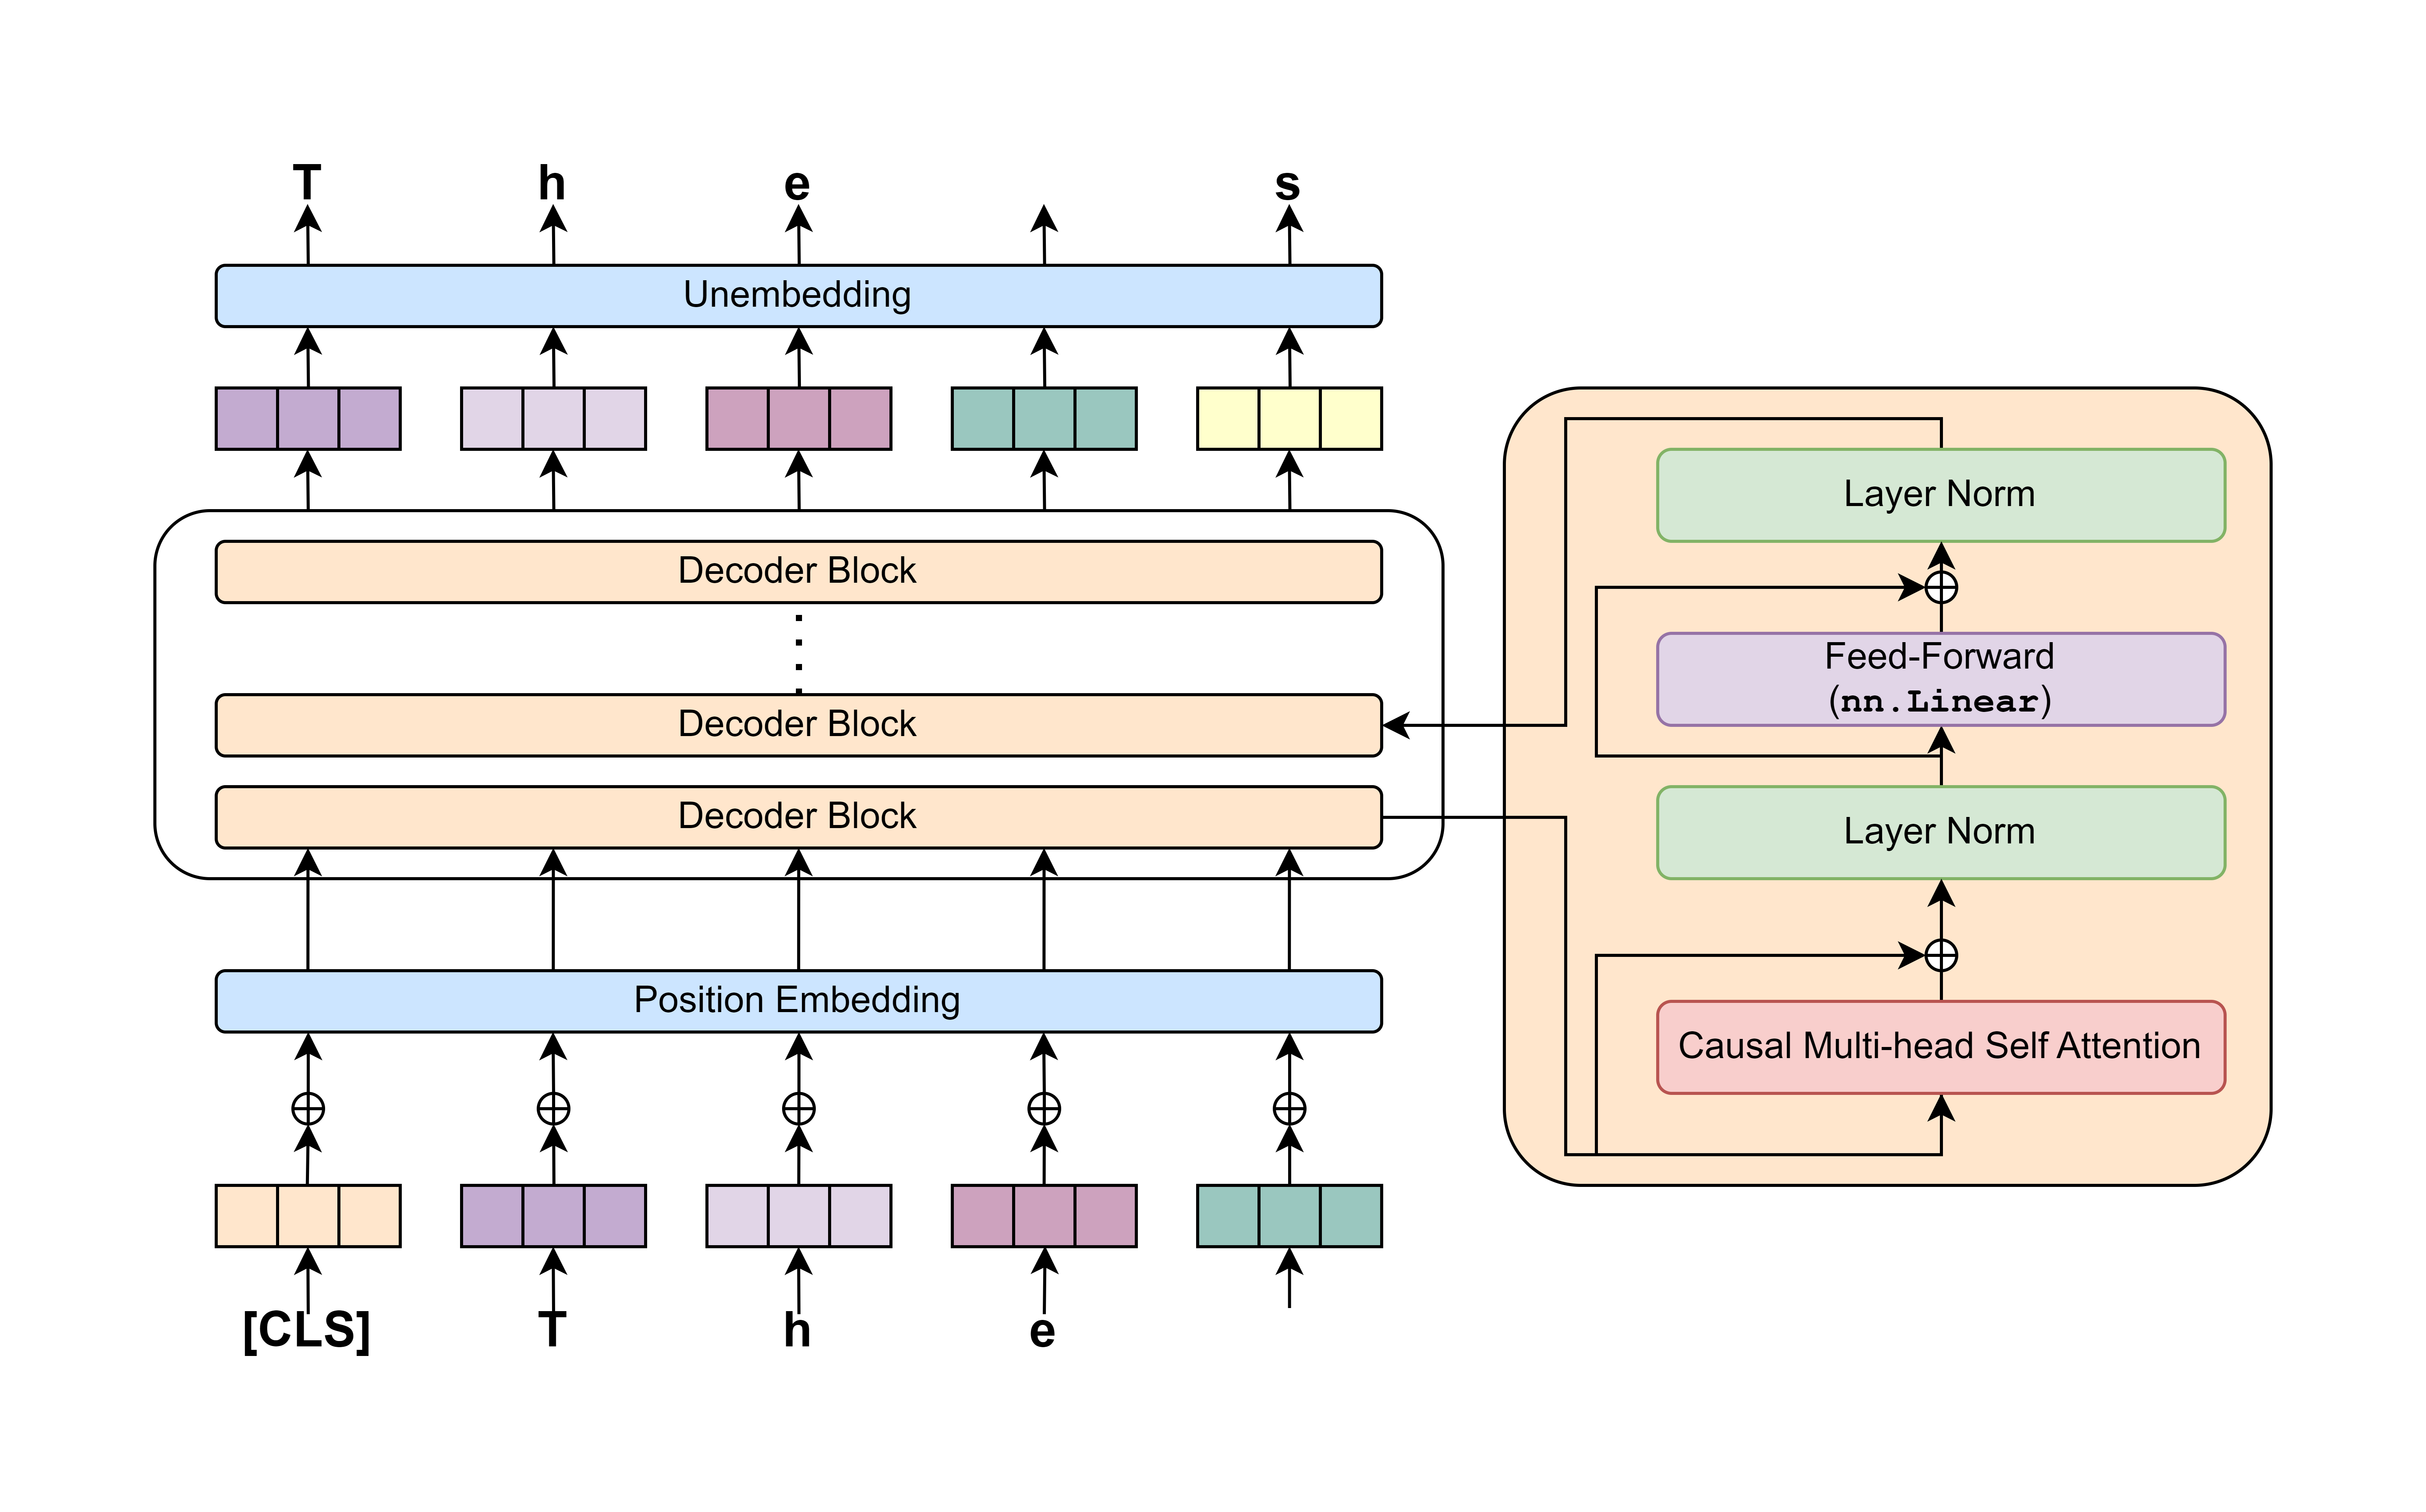


## Goals & Outputs

**Goal:** Train a char‑level LM that predicts the next character given all previous characters (causal / autoregressive).

**We will cover:**
1. Reproducible configuration & environment setup  
2. Dataset loading & sentence preparation (WikiText‑103 raw)  
3. Character vocabulary (including `<PAD>`, `<BOS>`, `<EOS>`, `<SEP>`)  
4. Tokenization at **character** level + padding/truncation strategy  
5. Model architecture in depth (embeddings → positional → Transformer layers with **causal mask** → LayerNorm → LM head)  
6. Loss, metrics, and why **perplexity** is the primary metric for language modeling  
7. Training loop with AMP, gradient clipping, AdamW, cosine LR schedule, checkpoints (best/last)  
8. Logging to CSV, saving plots (train loss, val loss, val perplexity), and a final report  
9. Practical stability/throughput tips + troubleshooting

**Artifacts produced in `save_dir/`:**
- `log_pretrain.csv`  (epoch-wise train/val metrics)  [loss and perplexity]
- `plot_pretrain_train_loss.png`, `plot_pretrain_val_loss.png`, `plot_pretrain_val_ppl.png`  
- `meta.json`  (vocab + model/training config)



## Prerequisites

Uncomment the following cell if you're in a fresh environment:


In [2]:

!pip install -q torch datasets tqdm matplotlib pandas

!pip install torch
!pip install numpy

!pip install torch
!pip install datasets



## 1) Config and Reproducibility

We define a simple dataclass `CFG` to keep all training knobs in one place.  
We also set seeds to make results repeatable (as much as possible).


In [3]:
import os, json, math, random, string, csv
from dataclasses import dataclass
from typing import List, Dict
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

@dataclass
class CFG:
    save_dir: str = "checkpoints_charLM" # the directory to which the checkpoints are saved
    subset_size: int = 500_000  # Size of the training dataset
    max_len: int = 256  # Context + generation length
    batch_size: int = 64  # training batch size
    num_workers: int = 2  # number of parallel GPUs to use
    d_model: int = 512  # dimensionality of the residual stream also the output dimension of the embedding layer.
    n_heads: int = 8  # Number of heads in the multi-head self attention block
    n_layers: int = 8 # Number of decoder blocks in the model
    dropout: float = 0.1  # dropout (if required)
    epochs: int = 5 # number of training epochs
    lr: float = 1e-4  # learning rate
    weight_decay: float = 0.01  # weight decay, applicable to AdamW loss
    grad_clip: float = 1.0  # Usually required so that we can prevent the model from changing the parameters by a large value due to a noisy batch
    seed: int = 42  # A seed to control the randomness introduced by torch, numpy or any other compute library

CFG = CFG()
os.makedirs(CFG.save_dir, exist_ok=True)

def set_seed(seed: int):
    '''Setting the seed for python random, numpy and torch and torch.cuda'''
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)


Device: cuda



## 2) Data Loading and Sentence Preparation




Downloads and prepares the dataset (e.g., WikiText/OpenWebText for LM or IMDb for sentiment).  
May perform lightweight sentence splitting, filtering by length, and shuffling.

**Expected outputs:** Printed counts (e.g., number of sentences/rows). First-time runs may download data and show progress bars.


In [4]:
from datasets import load_dataset

def load_wikitext_sentences(subset_size=None):

    ds = load_dataset("wikitext","wikitext-103-raw-v1", split="train")
    texts = [t.strip() for t in ds["text"] if t and len(t.strip()) > 0]
    sents = []
    for p in texts:
        p = p.replace("\n", " ")
        for s in p.split("."):
            s = s.strip()
            if 10 <= len(s) <= 300:
                sents.append(s)
    random.shuffle(sents)
    if subset_size is not None:
        sents = sents[:subset_size]
    return sents

print("Loading sentences...")
all_sents = load_wikitext_sentences(subset_size=CFG.subset_size)
print(f"Prepared sentences: {len(all_sents):,}")

Loading sentences...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00000-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

...

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Prepared sentences: 500,000



## 3) Character Vocabulary


**Task:** Implement a function that constructs a **character-level vocabulary** from a list of text sentences, including special symbols and extra characters.

#### Requirements
1. **Input:**
   - `sents`: a `List[str]` containing sentences.
   - `extra`: an optional `str` of additional characters to include in the vocabulary.

2. **Counting characters:**
   - Use Python’s `collections.Counter` to count all characters appearing in the sentences.
   - Update the counter to include the characters from `extra` even if they don’t appear in the data.

3. **Special tokens:**
   - Include the following tokens at the beginning of the vocabulary (with fixed indices):
     ```python
     SPECIAL = ['<PAD>', '<BOS>', '<EOS>', '<SEP>']
     ```
   - Assign each of these tokens a unique integer ID before adding other characters.

4. **Vocabulary construction:**
   - Build a **string-to-index mapping** (`stoi`) containing the special tokens first, then all remaining unique characters in sorted order.
   - Create the corresponding **index-to-string mapping** (`itos`) by reversing this mapping.

5. **Return values:**
   - The function `build_char_vocab` must return:
     ```python
     return stoi, itos
     ```

6. **Constants and usage:**
   - Extract the IDs of the special tokens as:
     ```python
     PAD_ID, BOS_ID, EOS_ID, SEP_ID = [stoi[t] for t in ['<PAD>', '<BOS>', '<EOS>', '<SEP>']]
     ```
   - Compute the total vocabulary size with `VOCAB_SIZE = len(stoi)`.

7. **Example behavior:**
   - If `all_sents` has more than 5000 sentences, use only the first 5000 to build the vocabulary.
   - Add common English letters, digits, punctuation, and newline characters using:
     ```python
     extra = string.ascii_letters + "0123456789 .,!?;:'\"-()[]\n"
     ```

The final code should print out the complete **vocabulary size** and produce valid lookup tables for character-level text processing.

<!-- Builds a character-level vocabulary (`stoi`/`itos`) from a small sample plus a safe extra alphabet.  
Ensures special tokens `<PAD>`, `<BOS>`, `<EOS>`, `<SEP>` are included.

**Expected outputs:** Printed vocab size. No files created yet. -->


In [ ]:
# INSERT CODE HERE

from collections import Counter
import string

def build_char_vocab(sents, extra = None):

    Special = ['<PAD>', '<BOS>', '<EOS>', '<SEP>']

    if len(sents) > 5000:
        sents = sents[:5000]

    counter = Counter()
    for sent in sents:
        counter.update(sent)

    if extra:
        counter.update(extra)

    chars = sorted(counter.keys())

    stoi = {}
    for i, token in enumerate(Special):
        stoi[token] = i

    for ch in chars:
        if ch not in stoi:  
            stoi[ch] = len(stoi)

    itos = {i: s for s, i in stoi.items()}

    PAD_ID, BOS_ID, EOS_ID, SEP_ID = [stoi[t] for t in Special]
    VOCAB_SIZE = len(stoi)

    print(f" Character vocabulary built successfully!")
    print(f"Total vocab size: {VOCAB_SIZE}")
    print(f"Special token IDs: PAD={PAD_ID}, BOS={BOS_ID}, EOS={EOS_ID}, SEP={SEP_ID}")

    return stoi, itos

extra = string.ascii_letters + "0123456789 .,!?;:'\"-()[]\n"

stoi, itos = build_char_vocab(all_sents, extra)

print("\nSample stoi entries:")
for k in list(stoi.keys())[:20]:
        print(f"{k!r}: {stoi[k]}")

print("\nSample itos entries:")
for i in range(min(20, len(itos))):
        print(f"{i}: {itos[i]!r}")



 Character vocabulary built successfully!
Total vocab size: 274
Special token IDs: PAD=0, BOS=1, EOS=2, SEP=3

Sample stoi entries:
'<PAD>': 0
'<BOS>': 1
'<EOS>': 2
'<SEP>': 3
'\n': 4
' ': 5
'!': 6
'"': 7
'#': 8
'$': 9
'%': 10
'&': 11
"'": 12
'(': 13
')': 14
'*': 15
'+': 16
',': 17
'-': 18
'.': 19

Sample itos entries:
0: '<PAD>'
1: '<BOS>'
2: '<EOS>'
3: '<SEP>'
4: '\n'
5: ' '
6: '!'
7: '"'
8: '#'
9: '$'
10: '%'
11: '&'
12: "'"
13: '('
14: ')'
15: '*'
16: '+'
17: ','
18: '-'
19: '.'



## 4) Tokenization and Collation (Character Level)


This code defines a **character-level language modeling dataset and data pipeline** using **PyTorch**. You are required to implement functions and data structures consistent with this design.

### Required Imports
You must import these essential modules and classes before using the code:
```python
import torch
from torch.utils.data import Dataset, DataLoader
```

### Key Components and Requirements
1. **Dataset Definition**  
   Implement a subclass of `torch.utils.data.Dataset` named `CleanCLMDataset`. It should:
   - Initialize with a list of text sequences (`sents`), a character-to-index dictionary (`stoi`), and a maximum sequence length (`max_len`).
   - Return the lowercase version of each text sample in `__getitem__`.
   - Provide the number of samples in `__len__`.

2. **Collate Function (`collate_clm`)**  
   Write a custom function to batch and pad character ID sequences. It should:
   - Use special tokens from `stoi`: `<PAD>`, `<BOS>`, `<EOS>`.
   - Convert each text sample into a list of token IDs: `[BOS] + [stoi[ch]] + [EOS]`.
   - Truncate or pad each sequence to `max_len` and assemble them into a `torch.LongTensor` of shape `(batch_size, T)`.

3. **Train–Validation Split**  
   Split your list of sequences (`all_sents`) into `train_sents` and `val_sents` using proportions or heuristics depending on dataset size.

4. **DataLoader Setup**  
   Construct `torch.utils.data.DataLoader` instances for training and validation:
   - `train_loader` uses shuffling (`shuffle=True`).  
   - `val_loader` does not shuffle (`shuffle=False`).  
   - Both use the `collate_clm` function for batching and may use multiple workers (`num_workers`) and pinned memory (`pin_memory=True`).

### Summary of Learning Goals
You should demonstrate understanding of:
- How to subclass and use `torch.utils.data.Dataset`.
- How to implement a `collate_fn` for sequence padding and batching.
- How to configure `DataLoader` for training and validation workflows.

<!--

Defines Dataset and Collate functions for:  
- **Clean CLM**: `[BOS] text [EOS]` sequences  
- **Denoise**: `[BOS] noisy [SEP] clean [EOS]` sequences  
Handles padding/truncation to `max_len` and returns batch tensors.

**Expected outputs:** No immediate output. Subsequent DataLoader cells will use these. -->


In [ ]:
# INSERT CODE HERE
class CleanCLMDataset(Dataset):
    def __init__(self, sents, stoi, max_len):
        
        self.sents = sents
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.sents)

    def __getitem__(self, idx):
        return self.sents[idx].lower()


def collate_clm(batch, stoi, max_len):
    
    PAD_ID, BOS_ID, EOS_ID = [stoi[t] for t in ['<PAD>', '<BOS>', '<EOS>']]

    batch_ids = []
    for sent in batch:
        ids = [stoi.get(ch, PAD_ID) for ch in sent]

        ids = [BOS_ID] + ids + [EOS_ID]

        if len(ids) > max_len:
            ids = ids[:max_len]
        else:
            ids = ids + [PAD_ID] * (max_len - len(ids))

        batch_ids.append(ids)

    batch_tensor = torch.LongTensor(batch_ids)

    return batch_tensor


def split_dataset(all_sents, val_ratio = 0.1):
    """
    Split sentences into train and validation sets.
    Uses a simple random shuffle.
    """
    random.shuffle(all_sents)
    split_idx = int(len(all_sents) * (1 - val_ratio))
    train_sents = all_sents[:split_idx]
    val_sents = all_sents[split_idx:]
    return train_sents, val_sents



def collate_fn(batch):
        return collate_clm(batch, stoi, CFG.max_len)

def get_dataloaders(all_sents, stoi, CFG):
    """
    Create DataLoaders for training and validation.
    """
    train_sents, val_sents = split_dataset(all_sents)

    train_dataset = CleanCLMDataset(train_sents, stoi, CFG.max_len)
    val_dataset = CleanCLMDataset(val_sents, stoi, CFG.max_len)


    train_loader = DataLoader(
        train_dataset,
        batch_size=CFG.batch_size,
        shuffle=True,
        num_workers=CFG.num_workers,
        pin_memory=True,
        collate_fn=collate_fn,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=CFG.batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        pin_memory=True,
        collate_fn=collate_fn,
    )

    print(f" Dataloaders ready:")
    print(f"  Train samples: {len(train_dataset)}")
    print(f"  Val samples:   {len(val_dataset)}")
    print(f"  Batch size:    {CFG.batch_size}")

    return train_loader, val_loader

train_loader, val_loader = get_dataloaders(all_sents, stoi, CFG)

for batch in train_loader:
    print(batch.shape)
    print(batch[0])
    break


 Dataloaders ready:
  Train samples: 450000
  Val samples:   50000
  Batch size:    64
torch.Size([64, 256])
tensor([ 1, 75, 86,  5, 89, 67, 85,  5, 86, 74, 71, 80,  5, 85, 71, 84, 88, 75,
        69, 71, 70,  5, 86, 81,  5, 84, 74, 91, 86, 74, 79, 75, 69,  5, 69, 81,
        80, 86, 71, 79, 82, 81, 84, 67, 84, 91,  5, 84, 67, 70, 75, 81,  5, 81,
        80,  5, 85, 71, 82, 86, 71, 79, 68, 71, 84,  5, 22, 21,  5, 17,  5, 23,
        21, 22, 24,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,


## 5) Model Architecture — Deep Dive


The provided code defines a class `CharDecoderLM`, which uses the `nn.TransformerEncoder` architecture to model sequential dependencies between characters in text.

#### Requirements and Structure
1. **Library Imports**  
   You must import and correctly use the following libraries and modules:
   ```python
   import torch
   import torch.nn as nn
   import math
   ```
   These provide tensor operations, neural network components, and mathematical utilities required for scaling embeddings and building the Transformer architecture.

2. **Model Design (`CharDecoderLM` Class)**  
   - **Embeddings:** The model creates two embedding layers—`tok_emb` for token (character) embeddings and `pos_emb` for positional encodings. Both use dimensions defined by `d_model`.
   - **Transformer Encoder:** The core of the model is a stack of Transformer encoder layers (`nn.TransformerEncoder`), each built from `nn.TransformerEncoderLayer`. These layers handle self-attention with `n_heads` and a feedforward network with dimension `d_model * 4`.
   - **Causal Masking:** A **causal attention mask** is applied to ensure the model only attends to previous positions during training, maintaining correct autoregressive behavior.
   - **Output Projection:** The final linear layer (`self.head`) projects the hidden states back to vocabulary logits for next-character prediction.

3. **Parameter Counting Function**  
   The helper function `count_parameters` counts both total and trainable parameters in the model, useful for reporting model size and verifying correct configuration.

4. **Model Configuration and Instantiation**  
   The model is configured using the `cfg_model` dictionary which specifies hyperparameters such as `d_model`, `n_heads`, `n_layers`, `max_len`, and `dropout`, and is initialized with a defined `VOCAB_SIZE` and moved to the available computation device.

5. **Expected Output**  
   When printing parameter counts, students should report both total and trainable parameters in millions for clarity.

#### Key Reminder
Ensure that:
- All required **imports** are at the top of your file.
- The **masking logic** uses `torch.triu()` and `float('-inf')` correctly to prevent information leakage from future tokens.
- The model is constructed and executed without errors using valid tensor shapes.

If you provide these components correctly, your model will form a functional **character-level Transformer decoder** suitable for autoregressive language modeling.

<!-- Defines the **CharDecoderLM**: token + positional embeddings → Transformer encoder stack → layer norm → LM head.  
Applies a causal mask so each position predicts the next character.

**Expected outputs:** No output now. Later cells will instantiate and print parameter counts. -->


In [ ]:
# INSERT CODE HERE
import torch
import torch.nn as nn

class CharDecoderLM(nn.Module):
   

    def __init__(self, vocab_size, d_model, n_heads,
                 n_layers, max_len, dropout = 0.1):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,  
            dropout=dropout,
            batch_first=True  
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        self.max_len = max_len
        self.d_model = d_model

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.xavier_uniform_(module.weight)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.constant_(module.bias, 0.0)

    def generate_causal_mask(self, seq_len, device):
       
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, idx):
        
        B, T = idx.shape
        device = idx.device

        tok_emb = self.tok_emb(idx)                               
        pos = torch.arange(0, T, device=device).unsqueeze(0)       
        pos_emb = self.pos_emb(pos)                                
        x = tok_emb + pos_emb                                      

        mask = self.generate_causal_mask(T, device=device)         

        x = self.encoder(x, mask=mask)                             

        x = self.ln_f(x)
        logits = self.head(x)                                      
        return logits


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total/1e6:.2f}M | Trainable: {trainable/1e6:.2f}M")
    return total, trainable



VOCAB_SIZE = len(stoi)

cfg_model = {
    "vocab_size": VOCAB_SIZE,   
    "d_model": CFG.d_model,
    "n_heads": CFG.n_heads,
    "n_layers": CFG.n_layers,
    "max_len": CFG.max_len,
    "dropout": CFG.dropout,
}

model = CharDecoderLM(**cfg_model).to(device)
print(f" Model initialized on {device}")
count_parameters(model)


 Model initialized on cuda
Total parameters: 25.63M | Trainable: 25.63M


(25631744, 25631744)


## 6) Loss and Metrics


The cross-entropy loss formula used in the code snippet for next-token prediction in language modeling is:

$$
\text{Loss} = -\sum_{i=1}^{|V|} y_i \log(\hat{y}_i)
$$

where:
- $|V|$ is the vocabulary size,
- $y_i$ is the true probability distribution (one-hot encoded, so only the correct token is 1, others are 0),
- $\hat{y}_i$ is the predicted probability for token $i$.

For a single target token $y_t$, this simplifies to:

$$
\text{Loss} = -\log(\hat{y}_{y_t})
$$

where $\hat{y}_{y_t}$ is the predicted probability for the correct next token at position $t$.

--

This code defines two helper functions essential for evaluating language models in natural language processing tasks.

The first function, `next_token_loss_full`, computes the **cross-entropy loss** for next-token prediction, which is a standard training objective in language modeling. It uses the `nn.CrossEntropyLoss` class from **PyTorch’s** `torch.nn` module, specifying `ignore_index=pad_id` to exclude padding tokens from contributing to the loss. The function shifts the logits and target token IDs by one position to ensure the model predicts the next token at each time step. Both tensors are reshaped with `.contiguous().view(-1, …)` to match the expected input shape for `CrossEntropyLoss`.

---

The formula for perplexity in language modeling, based on the cross-entropy loss, is:

$$
\text{Perplexity} = \exp(\text{Loss})
$$

where "Loss" is the average cross-entropy loss per token over the sequence. This formula directly matches the implementation in your code, where the loss value is exponentiated to obtain the perplexity.

---

The second function, `perplexity_from_loss`, converts a scalar loss value into **perplexity**, a common evaluation metric that measures how well a model predicts a sample. It uses the `math.exp()` function from Python’s **math** library and guards against overflow with a `try/except` block, returning infinity (`float('inf')`) if the exponential cannot be computed.

**Required imports:**
```python
import math
import torch.nn as nn
```
Be sure to import both before using these functions, as they rely on PyTorch’s neural network tools (`nn`) and the standard library `math` module.

<!-- Implements **next-token cross-entropy** for causal language modeling, ignoring `<PAD>`.  
Used during pretraining to minimize negative log-likelihood over all tokens.

**Expected outputs:** No output yet. Loss will appear in training logs. -->


In [ ]:
def next_token_loss_full(logits, targets, pad_id):
    
    logits = logits[:, :-1, :].contiguous()   
    targets = targets[:, 1:].contiguous()     

    logits_flat = logits.view(-1, logits.size(-1))
    targets_flat = targets.view(-1)

    criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
    loss = criterion(logits_flat, targets_flat)

    return loss


def perplexity_from_loss(loss):
    try:
        return math.exp(loss)
    except OverflowError:
        return float('inf')


## 7) Optimizer, Scheduler, AMP, Gradient Clipping


This code segment sets up the **optimizer**, **learning rate scheduler**, and **training logger** for a PyTorch-based NLP model pretraining pipeline. It uses several components from the `torch` library to manage optimization, mixed precision training, and logging.

#### Key Components

1. **Optimizer Setup**
   - The line
     ```python
     optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
     ```
     initializes the **AdamW optimizer** (from `torch.optim`) with parameters of the model. You should ensure that both `torch` and `torch.optim` are imported, and that `CFG` contains defined hyperparameters for `lr` (learning rate) and `weight_decay`.

2. **Gradient Scaling for Mixed Precision**
   - Mixed precision training is enabled through:
     ```python
     scaler = torch.amp.GradScaler('cuda', enabled=(device == 'cuda'))
     ```
     which comes from the `torch.amp` module. It helps maintain numerical stability and efficiency when training on CUDA-enabled GPUs.

3. **Learning Rate Scheduler**
   - The total number of training steps is computed, and the **CosineAnnealingLR** scheduler is initialized as:
     ```python
     steps_total = max(1, CFG.epochs * len(train_loader))
     scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps_total)
     ```
     This scheduler gradually reduces the learning rate following a **cosine function** over the total number of steps, which helps improve convergence.

4. **Logging Training Progress**
   - CSV logging is configured with:
     ```python
     log_csv = os.path.join(CFG.save_dir, "log_pretrain.csv")
     with open(log_csv, "w", newline="") as f:
         csv.writer(f).writerow(["epoch","train_loss","val_loss","val_perplexity","lr_last"])
     ```
     This ensures that during training, metrics such as losses and learning rates are recorded for later analysis. The `os` and `csv` modules must be imported for this to work.



      

#### Required Imports
Before running this code block, the following imports are **required**:
```python
import torch
import torch.optim
import torch.amp
import os
import csv
```

Confirm that `CFG`, `model`, `train_loader`, and `device` are defined in the training script prior to running this section.

<!-- Configures the runtime device.  
Seeds are set for reproducibility if present. -->




In [ ]:
# INSERT CODE HERE



import torch.optim
import torch.amp
import os
import csv


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay
)
print(f"Optimizer: AdamW (lr={CFG.lr}, weight_decay={CFG.weight_decay})")


scaler = torch.amp.GradScaler('cuda', enabled=(device == 'cuda'))
print(f" AMP enabled: {device == 'cuda'}")


steps_total = max(1, CFG.epochs * len(train_loader)) 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=steps_total
)
print(f"LR Scheduler: CosineAnnealingLR (T_max={steps_total})")


log_csv = os.path.join(CFG.save_dir, "log_pretrain.csv")

# Create the log file and write CSV header
with open(log_csv, "w", newline="") as f:
    csv.writer(f).writerow(["epoch", "train_loss", "val_loss", "val_perplexity", "lr_last"])

print(f"Training log initialized: {log_csv}")

Optimizer: AdamW (lr=0.0001, weight_decay=0.01)
 AMP enabled: True
LR Scheduler: CosineAnnealingLR (T_max=35160)
Training log initialized: checkpoints_charLM/log_pretrain.csv



## 8) Training and Validation Loops


This code snippet implements a **complete epoch loop** for training and validating a neural language model in **PyTorch** using **automatic mixed precision (AMP)**, gradient clipping, and a **learning rate scheduler**. You are expected to reproduce this functionality correctly as part of the assignment.

#### Key Requirements and Responsibilities
1. **Iterative Epoch Loop** — The code runs for `CFG.epochs` iterations. Each epoch includes both a **training** and **validation** phase.
2. **Training Phase** (`model.train()`):
   - The model is set to training mode using `model.train()`.
   - Mini-batches of tokenized inputs (`ids`) are drawn from `train_loader`.
   - Inside the loop, automatic mixed precision is applied using `torch.amp.autocast('cuda', enabled=(device == 'cuda'))` for efficient GPU computation.
   - The model’s forward pass produces `logits`, and a **next-token prediction loss** is computed using `next_token_loss_full(logits, ids, PAD_ID)`.
   - The backward pass is handled through a **gradient scaler** (`torch.cuda.amp.GradScaler`) to support mixed precision.
   - Gradients are clipped using `torch.nn.utils.clip_grad_norm_()` to prevent exploding gradients.
   - Optimizer and scheduler are updated each step, and running loss is recorded for progress display with `tqdm`.
3. **Validation Phase** (`model.eval()`):
   - The model is set to evaluation mode (`torch.no_grad()` disables gradient tracking).
   - The same loss function is used on `val_loader` batches to compute the average validation loss.
   - The model’s **perplexity** is computed via `perplexity_from_loss(val_loss)`.
4. **Logging :**
   - Save in log_pretrain.csv
#### Required Imports
Ensure the following key libraries and modules are properly imported:
```python
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import csv
```
Additionally, import all user-defined utilities referenced here:
- `next_token_loss_full()` – custom token-level loss function.
- `perplexity_from_loss()` – converts average loss to perplexity.
- `CFG` – configuration object containing hyperparameters (`epochs`, `grad_clip`, etc.).

***
**Instructor’s Note:** When re-creating this block, you must demonstrate correct usage of **autocast**, **GradScaler**, and **gradient clipping** to manage numerical stability during mixed-precision training on CUDA devices.

<!-- Train and validate the model. -->

In [ ]:

import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import csv


PAD_ID = stoi["<PAD>"]  
best_val_loss = float("inf")

for epoch in range(1, CFG.epochs + 1):
    scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
    print(f"\n Epoch {epoch}/{CFG.epochs}")

    #TRAINING PHASE
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, total=len(train_loader), desc=f"Training Epoch {epoch}")
    for ids in pbar:
        ids = ids.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(ids)
            loss = next_token_loss_full(logits, ids, PAD_ID)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        avg_train_loss = running_loss / (pbar.n + 1)
        pbar.set_postfix({"train_loss": f"{avg_train_loss:.4f}"})

    train_loss = running_loss / len(train_loader)


    #VALIDATION PHASE
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        pbar_val = tqdm(val_loader, total=len(val_loader), desc=f"Validating Epoch {epoch}")
        for ids in pbar_val:
            ids = ids.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                logits = model(ids)
                loss = next_token_loss_full(logits, ids, PAD_ID)
            val_loss += loss.item()
            avg_val_loss = val_loss / (pbar_val.n + 1)
            pbar_val.set_postfix({"val_loss": f"{avg_val_loss:.4f}"})

    val_loss /= len(val_loader)
    val_ppl = perplexity_from_loss(val_loss)


    #LOGGING & CHECKPOINTING
    lr_last = scheduler.get_last_lr()[0]

    print(
        f"Epoch {epoch}: "
        f"Train Loss={train_loss:.4f}, "
        f"Val Loss={val_loss:.4f}, "
        f"Val PPL={val_ppl:.4f}, "
        f"LR={lr_last:.6f}"
    )

    # Append results to CSV log
    log_csv = os.path.join(CFG.save_dir, "log_pretrain.csv")
    with open(log_csv, "a", newline="") as f:
        csv.writer(f).writerow([epoch, train_loss, val_loss, val_ppl, lr_last])

    # Save checkpoint if best validation loss improves
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        ckpt_path = os.path.join(CFG.save_dir, f"best_model_epoch{epoch}.pt")
        torch.save(model.state_dict(), ckpt_path)
        print(f"Saved new best model to {ckpt_path}")

print("\n Training complete!")



/tmp/ipython-input-3341830104.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))



 Epoch 1/5


Training Epoch 1:   0%|          | 0/7032 [00:00<?, ?it/s]/tmp/ipython-input-3341830104.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
Validating Epoch 1:   0%|          | 0/782 [00:00<?, ?it/s]/tmp/ipython-input-3341830104.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
Validating Epoch 1: 100%|██████████| 782/782 [01:02<00:00, 12.54it/s, val_loss=1.3324]


Epoch 1: Train Loss=1.6146, Val Loss=1.3324, Val PPL=3.7903, LR=0.000090
Saved new best model to checkpoints_charLM/best_model_epoch1.pt

 Epoch 2/5


Validating Epoch 2: 100%|██████████| 782/782 [01:01<00:00, 12.64it/s, val_loss=1.2459]


...

Epoch 3: Train Loss=1.2692, Val Loss=1.2052, Val PPL=3.3374, LR=0.000035
Saved new best model to checkpoints_charLM/best_model_epoch3.pt

 Epoch 4/5


Validating Epoch 4: 100%|██████████| 782/782 [01:01<00:00, 12.66it/s, val_loss=1.1858]


Epoch 4: Train Loss=1.2369, Val Loss=1.1858, Val PPL=3.2732, LR=0.000010
Saved new best model to checkpoints_charLM/best_model_epoch4.pt

 Epoch 5/5


Validating Epoch 5: 100%|██████████| 782/782 [01:01<00:00, 12.74it/s, val_loss=1.1807]


Epoch 5: Train Loss=1.2234, Val Loss=1.1807, Val PPL=3.2568, LR=0.000000
Saved new best model to checkpoints_charLM/best_model_epoch5.pt

 Training complete!



## 9) Plots: Train Loss, Val Loss, Val Perplexity


In [ ]:

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(log_csv)

plt.figure()
plt.plot(df["epoch"], df["train_loss"])
plt.xlabel("Epoch"); plt.ylabel("Train Loss"); plt.title("Pretrain Train Loss")
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(CFG.save_dir, "plot_pretrain_train_loss.png"), dpi=160)
plt.close()

plt.figure()
plt.plot(df["epoch"], df["val_loss"])
plt.xlabel("Epoch"); plt.ylabel("Val Loss"); plt.title("Pretrain Val Loss")
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(CFG.save_dir, "plot_pretrain_val_loss.png"), dpi=160)
plt.close()

plt.figure()
plt.plot(df["epoch"], df["val_perplexity"])
plt.xlabel("Epoch"); plt.ylabel("Val Perplexity"); plt.title("Pretrain Val Perplexity")
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(CFG.save_dir, "plot_pretrain_val_ppl.png"), dpi=160)
plt.close()

print("Saved plots in:", CFG.save_dir)


Saved plots in: checkpoints_charLM



## 10) Save `meta.json`




Serializes **meta.json**: vocabulary, inverse vocab, and run configuration.  
Enables consistent reload for downstream tasks.

**Expected outputs:** A `meta.json` .


In [ ]:

meta = {
    "stoi": stoi,
    "itos": {int(k): v for k, v in {i:s for s,i in stoi.items()}.items()},  # invert stable
    "cfg": {
        **cfg_model,
        "save_dir": CFG.save_dir,
        "subset_size": len(all_sents),
        "epochs": CFG.epochs,
        "lr": CFG.lr,
        "weight_decay": CFG.weight_decay,
        "grad_clip": CFG.grad_clip,
        "batch_size": CFG.batch_size,
        "num_workers": CFG.num_workers,
        "max_len": CFG.max_len,
        "seed": CFG.seed
    }
}
with open(os.path.join(CFG.save_dir, "meta.json"), "w") as f:
    json.dump(meta, f)
print("Saved meta.json")


Saved meta.json



## 11) Final Report


Just print results like val_preplexity of best model ,Sentences used to for val.Last epoch val_perplexity.
Also store log_pretrain.csv in format of epoch,train_loss,val_preplexity.

In [ ]:

import pandas as pd
df = pd.read_csv(log_csv)
last_row = df.iloc[-1]
print("\n=== Pretrain Report ===")
print(f"Sentences used         : {len(all_sents)}")
print(f"Epochs                 : {CFG.epochs}")
print(f"Best val perplexity    : {df['val_perplexity'].min():.3f} (epoch {df['val_perplexity'].idxmin()+1})")
print(f"Last epoch val perplex.: {last_row['val_perplexity']:.3f}")
print("Saved:", os.path.join(CFG.save_dir, "best_pretrain.pt"))
print("Saved:", os.path.join(CFG.save_dir, "last_pretrain.pt"))
print("Logs :", os.path.join(CFG.save_dir, "log_pretrain.csv"))



=== Pretrain Report ===
Sentences used         : 500000
Epochs                 : 5
Best val perplexity    : 3.257 (epoch 5)
Last epoch val perplex.: 3.257
Saved: checkpoints_charLM/best_pretrain.pt
Saved: checkpoints_charLM/last_pretrain.pt
Logs : checkpoints_charLM/log_pretrain.csv



## 12) Evaluation Guidance



- **Validation perplexity** is the primary metric. Lower is better.  
- Char‑level models typically show higher loss/perplexity than word‑level. Compare **relative** improvements across runs.  
- Track curves: healthy training → train loss goes down, val loss tends to flatten or decrease moderately.



# Two Downstream Tasks for Char-Level LM
We extend the original pretraining notebook with **two practical downstream tasks** built on the same character-level Transformer encoder:

1. **Spell-Correction (Denoising)** – target-only loss, CER evaluation, greedy decoding.
2. **IMDb Sentiment Classification** – classifier head, Accuracy/F1, ROC & AUROC.

Each section is fully runnable and includes clear explanations and metrics.


## Spell-Correction (Denoising) task
In the spell-correction (Denoising) task, you’ll explore how a **character-level language model** (you trained above) can learn to *"fix spelling mistakes"* by training it to transform noisy text into its correct form. You’ll start with a pretrained model and finetune it using pairs of text examples that show how a noisy input maps to its clean, denoised version.

Each example is formatted as:

```
<BOS> noisy text <SEP> denoised text <EOS>
```

Here, `<BOS>` marks the beginning of the sequence, `<SEP>` separates the noisy input from the target output, and `<EOS>` signals the end of the example.

For example:

```
<BOS> teh quik borwn fix <SEP> the quick brown fox <EOS>
```

During finetuning, the model learns to generate the corrected text after the `<SEP>` token, effectively modeling how characters should be changed, deleted, or inserted to fix common errors. This activity helps you understand how sequence-to-sequence learning works at the character level and deepens your intuition about noise-robust language modeling and text generation.




## Metrics

**Cross-Entropy (CE)**: token-level negative log-likelihood; lower is better.  
**Perplexity (PPL)**: $\exp(\text{CE})$. Measures how "surprised" the model is; lower is better.

**Levenshtein Distance**: minimal edits (insert/delete/substitute) to turn one string into another.  
**Character Error Rate (CER)**:  
$$ \text{CER} = \frac{\text{Levenshtein}(\text{prediction},\ \text{gold})}{\max(1, |\text{gold}|)} $$
Interprets spelling quality: 0.10 means ~10% of characters must change on average.

**Accuracy**: fraction of correct predictions.  
**Precision/Recall**: precision = TP/(TP+FP), recall = TP/(TP+FN).  
**F1**: harmonic mean of precision & recall.

**Receiver-operating characteristic (ROC) curve**: plots **TPR** vs **FPR** as threshold varies.  
**AUROC**: area under ROC; 0.5≈random, 1.0=perfect.



## 1) Environment & Quick Setup
This cell installs any missing libraries and configures device + seeds for reproducibility.


In [ ]:
import os, random, json, math
import numpy as np
import torch

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Device: cuda



## 2) Shared Utilities (implement all these)

### **Code Requirements and Description**

In this part of the assignment, you are required to implement a **character-level noise augmentation and evaluation module** for text data. The provided code defines helper functions to **add realistic noise** to strings (simulating typos, insertions, deletions, swaps, and character substitutions) and to **evaluate string similarity** using **Levenshtein distance** and **Character Error Rate (CER)**.

#### **Required Imports**

Make sure you include the following imports at the top of your script:

```python
from typing import Dict, List
from datasets import load_dataset
import random
```

#### **Functional Overview**

1. **`robust_as_stoi(x)` and `robust_as_itos(x)`**

   * These functions safely convert between **string-to-index (stoi)** and **index-to-string (itos)** mappings.
   * They ensure compatibility whether the input is a dictionary or a list-like sequence.

2. **Noise Generation (`apply_noise_ops`)**

   * Introduces random character-level noise to an input string with a specified probability (`p_char`).
   * Operations include:

     * **Deletion**, **Insertion**, **Swap**, **Keyboard-near replacements**, and **Homoglyph substitutions** (e.g., replacing `0` → `O`, `1` → `l`).
   * Occasional space removal or insertion further simulates real-world noisy text (e.g., OCR or typing errors).

3. **`_KEYBOARD_NEAR` and `_replace_near(ch)`**

   * `_KEYBOARD_NEAR` defines nearby keys for each alphabet character (approximating QWERTY layout).
   * `_replace_near(ch)` randomly substitutes a character with a neighboring key to mimic typing errors.

4. **Evaluation Metrics (`levenshtein` and `cer`)**

   * `levenshtein(a, b)` computes the edit distance between two strings using dynamic programming.
   * `cer(pred, gold)` calculates the **Character Error Rate**, normalized by the length of the reference string.

#### **Purpose**

This code is meant to help you:

* Understand **noise robustness** in NLP preprocessing.
* Explore how **string distance metrics** like Levenshtein and CER quantify textual degradation.
* Prepare noisy datasets for **error correction**, **robust text recognition**, or **language model evaluation** tasks.



<!-- - Robust `stoi/itos` loading from `meta.json`
- Noise injection ops (keyboard adjacency, deletion/insertion/swap).(write code which inject noise in sentences. )
- Levenshtein & CER -->


In [ ]:


from typing import Dict, List
from datasets import load_dataset 
import random


def robust_as_stoi(x):
    if isinstance(x, dict):
        stoi = {}
        for k, v in x.items():
            try:
                stoi[k] = int(v)
            except ValueError:
                stoi[k] = len(stoi)
        return stoi
    elif isinstance(x, list):
        return {s: i for i, s in enumerate(x)}
    else:
        raise TypeError("Invalid stoi format in meta.json")


def robust_as_itos(x):
    if isinstance(x, list):
        return [str(t) if not isinstance(t, str) else t for t in x]
    elif isinstance(x, dict):

        max_idx = max(int(v) for v in x.values())
        itos = [""] * (max_idx + 1)
        for s, i in x.items():
            itos[int(i)] = s
        return itos
        
    else:
        raise TypeError("Invalid itos format in meta.json")




#Approximate QWERTY neighbors (lowercase). 
_KEYBOARD_NEAR: Dict[str, List[str]] = {
    "q": ["w", "a"],
    "w": ["q", "e", "s"],
    "e": ["w", "r", "d"],
    "r": ["e", "t", "f"],
    "t": ["r", "y", "g"],
    "y": ["t", "u", "h"],
    "u": ["y", "i", "j"],
    "i": ["u", "o", "k"],
    "o": ["i", "p", "l"],
    "p": ["o"],
    "a": ["q", "s", "z"],
    "s": ["a", "w", "d", "x"],
    "d": ["s", "e", "f", "c"],
    "f": ["d", "r", "g", "v"],
    "g": ["f", "t", "h", "b"],
    "h": ["g", "y", "j", "n"],
    "j": ["h", "u", "k", "m"],
    "k": ["j", "i", "l"],
    "l": ["k", "o"],
    "z": ["a", "x"],
    "x": ["z", "s", "c"],
    "c": ["x", "d", "v"],
    "v": ["c", "f", "b"],
    "b": ["v", "g", "n"],
    "n": ["b", "h", "m"],
    "m": ["n", "j"],
    "1": ["2"],
    "2": ["1", "3"],
    "3": ["2", "4"],
    "4": ["3", "5"],
    "5": ["4", "6"],
    "6": ["5", "7"],
    "7": ["6", "8"],
    "8": ["7", "9"],
    "9": ["8", "0"],
    "0": ["9"],
    ".": [","],
    ",": ["."],
    "-": ["="],
    " ": [" "],
}

_HOMOGLYPHS = {
    "0": "O", "O": "0",
    "1": "l", "l": "1", "I": "l", "i": "l",
    "5": "S", "S": "5",
    "2": "Z", "Z": "2",
    "8": "B", "B": "8",
    "c": "k", "k": "c",
    "m": "rn",
    "rn": "m",
}


def _replace_near(ch, rng):
    if not ch:
        return ch
    lower = ch.lower()
    if lower in _KEYBOARD_NEAR:
        candidates = _KEYBOARD_NEAR[lower]
        if candidates:
            rep = rng.choice(candidates)
            # preserve case
            return rep.upper() if ch.isupper() else rep
    return ch


def _replace_homoglyph(ch):
    return _HOMOGLYPHS.get(ch, ch)



def apply_noise_ops(
    s,
    p_char = 0.10,
    space_del_prob = 0.02,
    space_ins_prob = 0.02,
    rng: random.Random = None,
    alphabet= None,
):

    rng = rng or random.Random()

    if alphabet is None:
        alphabet = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.,!?;:'\"-()[]{} "

    chars = list(s)
    i = 0
    out = []

    while i < len(chars):
        ch = chars[i]
        if rng.random() < p_char:
            # choose an operation
            op = rng.choice(["del", "ins", "swap", "near", "homo"])
            if op == "del":
                # skip appending ch (delete)
                i += 1
                continue

            elif op == "ins":
                out.append(rng.choice(alphabet))
                out.append(ch)
                i += 1
                continue

            elif op == "swap":
                if i + 1 < len(chars):
                    out.append(chars[i + 1])
                    out.append(ch)
                    i += 2
                    continue
                else:
                    # nothing to swap with; fall back to append
                    out.append(ch)
                    i += 1
                    continue

            elif op == "near":
                out.append(_replace_near(ch, rng))
                i += 1
                continue

            elif op == "homo":
                out.append(_replace_homoglyph(ch, rng))
                i += 1
                continue

        # no op
        out.append(ch)
        i += 1

    noisy = "".join(out)

    # Occasional space deletions/insertions
    if " " in noisy and rng.random() < space_del_prob:
        idxs = [i for i, c in enumerate(noisy) if c == " "]
        if idxs:
            k = rng.choice(idxs)
            noisy = noisy[:k] + noisy[k + 1 :]

    if rng.random() < space_ins_prob:
        k = rng.randrange(0, len(noisy) + 1)
        noisy = noisy[:k] + " " + noisy[k:]

    return noisy


#Levenshtein distance & CER
def levenshtein(a, b):

    if a == b:
        return 0
    if len(a) == 0:
        return len(b)
    if len(b) == 0:
        return len(a)

    if len(a) > len(b):
        a, b = b, a

    previous = list(range(len(a) + 1))
    for j, bj in enumerate(b, start=1):
        current = [j]
        for i, ai in enumerate(a, start=1):
            insert_cost = current[i - 1] + 1
            delete_cost = previous[i] + 1
            sub_cost = previous[i - 1] + (0 if ai == bj else 1)
            current.append(min(insert_cost, delete_cost, sub_cost))
        previous = current
    return previous[-1]


def cer(pred, gold):

    if len(gold) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return levenshtein(pred, gold) / len(gold)





## 4) CharDecoderLM (Backbone)

### Code Description — Character-Level Transformer Decoder Language Model

This code defines a **character-level Transformer-based language model** implemented using **PyTorch**. You are required to correctly import and use the following Python libraries and modules:

```python
import torch
import torch.nn as nn
import math
```

The model is encapsulated in the class `CharDecoderLM(nn.Module)`, which subclasses `torch.nn.Module`. It implements a **causal Transformer encoder** used for **autoregressive character prediction** (e.g., in spell-correction or text generation tasks).

#### Key Components

* **Embedding Layers:**

  * `nn.Embedding(vocab_size, d_model)` creates token embeddings.
  * `nn.Embedding(max_len, d_model)` provides positional embeddings.
* **Transformer Encoder:**

  * Constructed using `nn.TransformerEncoderLayer` with parameters `d_model`, `nhead`, and `dim_feedforward=d_model*4`.
  * Stacked into multiple layers with `nn.TransformerEncoder`.
* **Normalization and Output:**

  * `nn.LayerNorm(d_model)` normalizes the hidden representations.
  * `nn.Linear(d_model, vocab_size)` serves as the output (language modeling) head.

#### Forward Pass

The `forward()` method:

1. Embeds the input token indices and adds positional encodings (scaled by `√d_model`).
2. Constructs a **causal attention mask** using `torch.triu()` to ensure the model cannot attend to future tokens.
3. Passes the sequence through the Transformer encoder.
4. Applies layer normalization and projects the hidden states to vocabulary logits.

The `forward_hidden()` method is similar but returns the normalized hidden representations before the output layer, which can be used for **downstream tasks** like sequence classification or feature extraction.

---

This section of the assignment expects students to demonstrate understanding of:

* Correct use of **PyTorch neural network modules**.
* Implementation of **causal self-attention masking**.
* Handling of **positional and token embeddings** in Transformer architectures.


<!-- A causal character-level Transformer encoder with token & positional embeddings.  
We’ll reuse its hidden states for both tasks (decoder head for spell-correction; MLP head for sentiment). -->


In [ ]:
class CharDecoderLM(nn.Module):


    def __init__(self, vocab_size, d_model, n_heads,
                 n_layers, max_len, dropout = 0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_len = max_len

        # Embeddings
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.xavier_uniform_(m.weight)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    @staticmethod
    def _causal_mask(T, device):

        m = torch.triu(torch.ones(T, T, device=device), diagonal=1)
        return m.masked_fill(m == 1, float("-inf"))

    def forward_hidden(self, idx):

        B, T = idx.shape
        device = idx.device

        # Token + positional embeddings (scale by sqrt(d_model))
        x = self.tok_emb(idx) * math.sqrt(self.d_model)
        pos = torch.arange(T, device=device).unsqueeze(0)  
        x = x + self.pos_emb(pos)                          

        # Causal self-attention mask
        mask = self._causal_mask(T, device)              

        # Transformer encoding
        x = self.encoder(x, mask=mask)                    

        # Final norm
        x = self.ln_f(x)                                  
        return x

    def forward(self, idx):
        h = self.forward_hidden(idx)                      
        logits = self.head(h)                             
        return logits


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params: {total/1e6:.2f}M | Trainable: {trainable/1e6:.2f}M")
    return total, trainable



## 5) Load Pretrained Artifacts(model)
Update the directories below to point to your **pretrained** `meta.json` and `best_pretrain.pt` for each task.




Part of the pipeline (supporting utilities or glue code). Reads configs/objects, prepares tensors, or orchestrates a step.

**Expected outputs:** Minimal prints. Files or plots only if explicitly saved in this cell.


In [13]:
meta_path = "/content/meta.json"

with open(meta_path, "r") as f:
    meta = json.load(f)

itos_dict = meta["itos"]

itos_list = [None] * len(itos_dict)
for k, v in itos_dict.items():
    itos_list[int(k)] = v


In [ ]:

import os, json

BASE_DIR_SPELL = ""          # contains meta.json + best_pretrain.pt for spell-correction fine-tune
BASE_DIR_SENT  = ""    # contains meta.json + best_pretrain.pt for sentiment fine-tune

def load_meta_and_ckpt(base_dir: str):
    meta_path = os.path.join(base_dir, "/content/meta.json")
    ckpt_path = os.path.join(base_dir, "/content/best_model_epoch5.pt")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"meta.json missing at {meta_path}")
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"best_pretrain.pt missing at {ckpt_path}")
    with open(meta_path, "r") as f:
        meta = json.load(f)
    stoi = robust_as_stoi(meta["stoi"])
    itos = robust_as_itos(meta["itos"])
    cfg  = meta["cfg"]
    return stoi, itos, cfg, ckpt_path

# Load for both tasks
stoi_spell, itos_spell, cfg_spell, ckpt_spell = load_meta_and_ckpt(BASE_DIR_SPELL)
stoi_sent,  itos_sent,  cfg_sent,  ckpt_sent  = load_meta_and_ckpt(BASE_DIR_SENT)

print("Spell-Correction BASE:", BASE_DIR_SPELL)
print("Sentiment BASE       :", BASE_DIR_SENT)


Spell-Correction BASE: 
Sentiment BASE       : 



# Part A — Spell-Correction (Denoising Fine-tune) [Implementation - 100 Marks]

### 🧠 Assignment Snippet: Denoising Dataset Prep for WikiText

This part of your assignment is all about **building a small data pipeline** that takes text from the **WikiText dataset**, slices it into clean sentences, and prepares it for a **character-level denoising language model**.

You’ll need to make sure you’ve imported **everything you need**, especially from the following libraries:

```python
import random
import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
```

(and of course, any helper functions like `apply_noise_ops` you define yourself).

---

### 🧩 What This Code Does

1. **Loads the WikiText dataset** using `load_dataset("wikitext", "wikitext-103-raw-v1")` and extracts reasonably sized sentences. The `load_wikitext_sentences()` function does a light cleanup — removing super short lines and splitting paragraphs into sentences.

2. **Splits the data** into:

   * `pre_sents`: a big chunk for pretraining (up to 1 million sentences),
   * `ft_train_sents` and `ft_val_sents`: fine-tuning splits, with 95% used for training and 5% for validation.
     That’s all handled by `split_12_lakh_plan()`.

3. **Creates a PyTorch Dataset** (`DenoiseDataset`) that:

   * Takes each clean sentence,
   * Randomly corrupts it using your `apply_noise_ops()` function (the “denoising” part),
   * Returns the pair `(noisy, clean)`.

4. **Collates batches** in `collate_denoise()` by:

   * Converting characters to integer IDs using `stoi` (your char-to-index dictionary),
   * Adding special tokens like `<BOS>`, `<SEP>`, and `<EOS>`,
   * Padding everything to a fixed length.

5. **Wraps it all up** in a `DataLoader` for efficient batching and shuffling during training and validation.

---

### ⚙️ Configuration and Parameters

The bottom section defines hyperparameters and training options — things like `MAX_LEN_SPELL`, `D_MODEL_SPELL`, `BATCH_SIZE_SP`, `LR_SP`, etc. You can tweak these for faster runs by turning on `QUICK_RUN_SPELL = True`, which loads a smaller subset.

---

### 💡 TL;DR for Students

This snippet gives you the **data loading and preprocessing backbone** for a character-level denoising model. Your job will be to:

* Make sure you’ve imported everything (especially `datasets`, `torch`, and `random`),
* Implement or understand how `apply_noise_ops()` works,
* Understand how the clean/noisy sentence pairs get tokenized and batched,
* And be ready to plug this into your model training loop later!


<!-- **Goal**: Learn to map noisy text back to clean text.  
**Sequence**: `[BOS] noisy ... [SEP] clean ... [EOS]`  
**Loss**: *Target-only next-token loss* — we mask labels **before** `[SEP]` so the model is only supervised on the clean segment.  
**Metric**: **CER** on validation via greedy decoding. -->



### A.1 Config and Data



In [ ]:
import random
import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

QUICK_RUN_SPELL   = True
MAX_SENTENCES_ALL = 1_000_000
FT_SPLIT_RATIO    = 0.95
IGNORE_INDEX      = -100
PAD_ID            = None


def _simple_sent_split(paragraph):
    out = []
    buff = []
    for ch in paragraph:
        buff.append(ch)
        if ch in ".!?":
            sent = "".join(buff).strip()
            if len(sent) >= 5:
                out.append(sent)
            buff = []
    # tail
    tail = "".join(buff).strip()
    if len(tail) >= 5:
        out.append(tail)
    return out

def load_wikitext_sentences(quick= True, max_total= MAX_SENTENCES_ALL):

    ds = load_dataset("wikitext", "wikitext-103-raw-v1")
    sentences = []

    iterable = ds["train"]["text"]
    if quick:
        iterable = iterable[:50_000]  # small subset for quick iterations

    for para in iterable:
        if not para or len(para.strip()) < 5:
            continue
        # basic cleanup
        para = para.replace("==", " ").replace("  ", " ").strip()
        # split into sentences
        sents = _simple_sent_split(para)
        for s in sents:
            s = s.strip()
            if 5 <= len(s) <= 3000:  
                sentences.append(s)
                if len(sentences) >= max_total:
                    return sentences
    return sentences

#Split plan for pretrain / finetune
def split_12_lakh_plan(all_sents, ft_ratio=0.05):

    random.shuffle(all_sents)
    pre_sents = all_sents[: min(len(all_sents), MAX_SENTENCES_ALL)]
    n = len(pre_sents)
    cut = int((1.0 - ft_ratio) * n)
    ft_train_sents = pre_sents[:cut]
    ft_val_sents   = pre_sents[cut:]
    return pre_sents, ft_train_sents, ft_val_sents

#Denoising dataset
class DenoiseDataset(Dataset):

    def __init__(self, clean_sents, noise_kwargs=None):
        self.clean_sents = clean_sents
        self.noise_kwargs = noise_kwargs or {"p_char": 0.12}

    def __len__(self):
        return len(self.clean_sents)

    def __getitem__(self, idx):
        clean = self.clean_sents[idx]
        noisy = apply_noise_ops(clean, **self.noise_kwargs)
        return noisy, clean

#Collate: build input_ids & labels
def _encode_with_specials(noisy, clean, stoi, max_len):
    """
    Build token id sequence: [BOS] noisy [SEP] clean [EOS], truncated/padded to max_len.
    Returns ids (list[int]) and sep_index (int or None if SEP clipped out).
    """
    BOS_ID = stoi["<BOS>"]; SEP_ID = stoi["<SEP>"]; EOS_ID = stoi["<EOS>"]; PAD_ID = stoi["<PAD>"]

    seq_chars = ["<BOS>"] + list(noisy) + ["<SEP>"] + list(clean) + ["<EOS>"]
    ids = []
    for ch in seq_chars:
        if ch in ("<BOS>", "<SEP>", "<EOS>", "<PAD>"):
            ids.append(stoi[ch])
        else:
            ids.append(stoi.get(ch, PAD_ID))

    if len(ids) > max_len:
        ids = ids[:max_len]

    try:
        sep_idx = ids.index(SEP_ID)
    except ValueError:
        sep_idx = None

    # pad
    if len(ids) < max_len:
        ids = ids + [PAD_ID] * (max_len - len(ids))

    return ids, sep_idx

def collate_denoise(batch, stoi, max_len):

    PAD_ID = stoi["<PAD>"]
    input_ids = []
    sep_positions = []

    for noisy, clean in batch:
        ids, sep_idx = _encode_with_specials(noisy, clean, stoi, max_len)
        input_ids.append(ids)
        sep_positions.append(sep_idx)

    input_ids = torch.LongTensor(input_ids)          
    attn_mask = (input_ids != PAD_ID).long()        

    labels = input_ids.clone()
    labels[:, :-1] = input_ids[:, 1:]
    labels[:, -1] = PAD_ID

    # Ignore padding positions
    labels[input_ids == PAD_ID] = IGNORE_INDEX

    SEP_ID = stoi["<SEP>"]
    # For each row, mask labels <= SEP position
    for b in range(input_ids.size(0)):
        row = input_ids[b]
        # locate SEP after truncation/padding
        try:
            sep_pos = (row == SEP_ID).nonzero(as_tuple=True)[0]
            if len(sep_pos) > 0:
                sep_j = int(sep_pos[0].item())
                labels[b, : sep_j + 1] = IGNORE_INDEX
        except Exception:
            pass

    return {
        "input_ids": input_ids,
        "labels": labels,
        "attn_mask": attn_mask,
    }


#Build DataLoaders
def make_denoise_loaders(
    stoi: dict,
    batch_size: int = 64,
    max_len: int = 256,
    num_workers: int = 2,
    pin_memory: bool = True,
    quick: bool = QUICK_RUN_SPELL,
):
    all_sents = load_wikitext_sentences(quick=quick)
    _, ft_train_sents, ft_val_sents = split_12_lakh_plan(all_sents, ft_ratio=0.05)

    train_ds = DenoiseDataset(ft_train_sents, noise_kwargs={"p_char": 0.12})
    val_ds   = DenoiseDataset(ft_val_sents,   noise_kwargs={"p_char": 0.12})

    def _collate(batch):
        return collate_denoise(batch, stoi=stoi, max_len=max_len)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory, collate_fn=_collate
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory, collate_fn=_collate
    )

    print(f"Denoising data ready | Train: {len(train_ds)} | Val: {len(val_ds)} | max_len={max_len}")
    return train_loader, val_loader



In [ ]:
:
:

Denoising data ready | Train: 116182 | Val: 6115 | max_len=256
Train/Val Loaders ready!
Train batch shape: input_ids=torch.Size([64, 256]), labels=torch.Size([64, 256])



### A.2 Loss: Target-only Next-Token

### 🧠 Code Snippet: `next_token_loss_target_only`

This function computes a **cross-entropy loss** for next-token prediction, but with a twist — it ignores everything **before a special separator token (`sep_id`)** in each sequence.

Here’s what’s going on:

* We’re using **PyTorch**, so make sure to `import torch.nn as nn` before running this code.
* Inside, we create a **cross-entropy loss function** via `nn.CrossEntropyLoss(ignore_index=pad_id)`. The `ignore_index` makes sure that any positions with the padding token (`pad_id`) are skipped during loss calculation.
* The function expects:

  * `logits`: model predictions of shape `[batch, time, vocab_size]`
  * `ids`: the ground truth token IDs of shape `[batch, time]`
  * `sep_id`: a special token marking the start of the *target* portion of the sequence
  * `pad_id`: token ID used for padding

The clever part:
For each sequence, it finds where the `sep_id` occurs and **masks all tokens before it** by setting them to `pad_id`. That way, the model is only penalized for predictions *after* the separator — i.e., the *target* portion.

Finally, it chops off the last time step of `logits` (since we’re predicting the *next* token) and flattens both tensors to feed into the loss function.

So, in short — this function trains the model to focus only on predicting tokens **after the separator**, ignoring the input part of the sequence.

<!-- We mask all labels **before** `[SEP]` so only the clean target contributes to the loss. -->


In [16]:

def next_token_loss_target_only(logits, ids, sep_id, pad_id):

    labels = ids.clone()

    # Mask everything before/including SEP
    for b in range(ids.size(0)):
        sep_positions = (ids[b] == sep_id).nonzero(as_tuple=True)[0]
        if len(sep_positions) > 0:
            sep_idx = sep_positions[0].item()
            labels[b, : sep_idx + 1] = -100  # mask (IGNORE_INDEX)

    # Shift for next-token prediction
    logits = logits[:, :-1, :]
    labels = labels[:, 1:]

    B, T, V = logits.shape
    logits = logits.contiguous().view(B * T, V)
    labels = labels.contiguous().view(B * T)

    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
    loss = loss_fn(logits, labels)
    return loss

In [17]:
BATCH_SIZE_SPELL = cfg_spell.get("batch_size", 64)
MAX_LEN_SPELL    = cfg_spell.get("max_len", 256)

train_loader_sp, val_loader_sp = make_denoise_loaders(
    stoi=stoi_spell,
    batch_size=BATCH_SIZE_SPELL,
    max_len=MAX_LEN_SPELL,
    num_workers=2,
    pin_memory=True,
    quick=True
)

example_batch = next(iter(train_loader_sp))
print(f"Train/Val Loaders ready!")
print(f"Train batch shape: input_ids={example_batch['input_ids'].shape}, labels={example_batch['labels'].shape}")


Denoising data ready | Train: 116182 | Val: 6115 | max_len=256
Train/Val Loaders ready!
Train batch shape: input_ids=torch.Size([64, 256]), labels=torch.Size([64, 256])



### A.3 Train Loop + CER Validation

### 🧙‍♂️ Spell Fine-Tuning Script (a.k.a. the “Fix My Typos” Engine)

This part of your assignment is all about **fine-tuning a character-level Transformer** to clean up noisy or misspelled text — basically teaching your model to become a spell-checking wizard. 🪄

Before you dive in, make sure you’ve imported all the essentials:

* `torch`, `torch.nn`, and `torch.optim` for the deep learning backbone
* `tqdm` for those cool progress bars
* `csv` and `os` for saving logs and model checkpoints like a responsible ML engineer 😎

---

### What This Code Does:

1. **Setup & Configuration:**
   It creates a folder to store everything (`SAVE_DIR_SPELL`) and pulls out the special token IDs (`<PAD>`, `<BOS>`, `<EOS>`, `<SEP>`) from the vocabulary mappings (`stoi_spell`).

2. **Model Loading:**
   A `CharDecoderLM` Transformer model is initialized and loaded with pre-trained weights (`ckpt_spell`). So we’re not training from scratch — we’re giving the model a “spell correction” head-start.

3. **Optimization Magic:**
   The code sets up:

   * **AdamW optimizer** for weight updates,
   * **GradScaler** for mixed-precision training (so your GPU doesn’t melt 🔥),
   * **CosineAnnealingLR scheduler** to smoothly adjust learning rates during training.

4. **Training Loop:**
   For each epoch, it runs through batches of data (`train_loader_sp`), calculates the **next-token loss** (using `next_token_loss_target_only`), backpropagates, clips gradients, and updates weights.

   * Progress is shown using `tqdm`
   * Training losses are logged in `log_spell_ft.csv`

5. **Validation Phase:**
   After each epoch, it checks how well the model corrects noisy text by:

   * Generating predictions via a **greedy decoding** function (`generate_greedy`),
   * Computing the **Character Error Rate (CER)** against the ground truth clean text.

   The lower the CER, the better the model spells! 🧠


6. **All Done:**
   After training finishes, it prints the best CER achieved — your model’s spelling report card!

---

In short: this script fine-tunes a Transformer on a noisy text dataset to make it better at spelling correction. Your job is to fill in any missing pieces (like the dataset loaders, constants, or helper functions), make sure all the imports are correct, and get that **CER** as low as possible! 🚀


<!-- We load the pretrained encoder weights and fine-tune.  
Validation computes **CER** using greedy generation of the clean segment. -->


In [35]:
#Fine-Tuning CharDecoderLM (Fast CER Logging)

import os, csv, torch
from torch import nn, optim
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import numpy as np

SAVE_DIR_SPELL = "experiments/results/q1"
os.makedirs(SAVE_DIR_SPELL, exist_ok=True)

PAD_ID, BOS_ID, EOS_ID, SEP_ID = [stoi_spell[t] for t in ['<PAD>', '<BOS>', '<EOS>', '<SEP>']]

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

#Load pretrained model
model = CharDecoderLM(
    vocab_size=len(stoi_spell),
    d_model=cfg_spell["d_model"],
    n_heads=cfg_spell["n_heads"],
    n_layers=cfg_spell["n_layers"],
    max_len=cfg_spell["max_len"],
    dropout=cfg_spell.get("dropout", 0.1),
)
state_dict = torch.load(ckpt_spell, map_location=device)
model.load_state_dict(state_dict, strict=False)
model = model.to(device)
print("Loaded pretrained weights for spell correction.")


#Optimizer + Scheduler + Scaler

optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
scaler = GradScaler(enabled=(device == "cuda"))
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

log_csv = os.path.join(SAVE_DIR_SPELL, "log_spell_ft.csv")
with open(log_csv, "w", newline="") as f:
    csv.writer(f).writerow(["epoch", "train_loss", "val_loss", "val_cer", "lr_last"])


#Helpers
def levenshtein(a, b):
    dp = np.zeros((len(a)+1, len(b)+1), dtype=int)
    dp[:,0] = np.arange(len(a)+1)
    dp[0,:] = np.arange(len(b)+1)
    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            cost = 0 if a[i-1]==b[j-1] else 1
            dp[i,j] = min(dp[i-1,j]+1, dp[i,j-1]+1, dp[i-1,j-1]+cost)
    return dp[len(a), len(b)]

def cer(preds, targets):
    total, dist = 0, 0
    for p, t in zip(preds, targets):
        total += len(t)
        dist += levenshtein(p, t)
    return dist / max(total, 1)

@torch.no_grad()
def generate_greedy(model, input_ids, itos, sep_id, eos_id, max_len=128):
    """Shortened greedy decoding for validation (much faster)."""
    model.eval()
    out = input_ids.clone()
    vocab_size = len(itos)
    for _ in range(max_len):
        if out.size(1) > model.max_len:
            out = out[:, -model.max_len:]
        logits = model(out)
        next_token = logits[:, -1, :].argmax(-1)
        out = torch.cat([out, next_token.unsqueeze(1)], dim=1)
        if torch.all(next_token == eos_id):
            break
    texts = []
    for seq in out:
        seq_list = [itos[i] if i < len(itos) else "" for i in seq.tolist()]
        if "<SEP>" in seq_list:
            seq_list = seq_list[seq_list.index("<SEP>") + 1:]
        if "<EOS>" in seq_list:
            seq_list = seq_list[:seq_list.index("<EOS>")]
        texts.append("".join([ch for ch in seq_list if ch not in ["<PAD>", "<BOS>", "<SEP>", "<EOS>"]]))
    return texts

#Training Loop

EPOCHS_SPELL = 3
best_cer = float("inf")

for epoch in range(1, EPOCHS_SPELL + 1):
    print(f"\n🔹 Epoch {epoch}/{EPOCHS_SPELL}")
    model.train()
    running_loss = 0.0


    #Training

    pbar = tqdm(train_loader_sp, desc=f"Training Spell Epoch {epoch}")
    for batch in pbar:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=(device == "cuda")):
            logits = model(input_ids)
            loss = next_token_loss_target_only(logits, labels, SEP_ID, PAD_ID)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        avg_loss = running_loss / (pbar.n + 1)
        pbar.set_postfix({"train_loss": f"{avg_loss:.4f}"})

    train_loss = running_loss / len(train_loader_sp)


    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [],[]

    max_val_batches = int(np.ceil(1000 / val_loader_sp.batch_size))
    val_iter = tqdm(enumerate(val_loader_sp), desc=f"Validating Epoch {epoch}", total=max_val_batches)

    with torch.no_grad(), autocast(enabled=(device == "cuda")):
        for i, batch in val_iter:
            if i >= max_val_batches:
                break  # Limit validation to ~1000 samples

            input_ids = batch["input_ids"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            # Compute loss
            logits = model(input_ids)
            loss = next_token_loss_target_only(logits, labels, SEP_ID, PAD_ID)
            val_loss += loss.item()

            # Generate predictions (fast greedy)
            preds = generate_greedy(model, input_ids, itos_spell, SEP_ID, EOS_ID, max_len=128)

            for lab in labels:
                seq = [itos_spell[i.item()] for i in lab if i != PAD_ID]
                if "<SEP>" in seq:
                    seq = seq[seq.index("<SEP>")+1:]
                if "<EOS>" in seq:
                    seq = seq[:seq.index("<EOS>")]
                clean = "".join([c for c in seq if c not in ["<PAD>", "<BOS>", "<SEP>", "<EOS>"]])
                all_targets.append(clean)

            all_preds.extend(preds)

    val_loss /= max_val_batches
    val_cer = cer(all_preds, all_targets)
    lr_last = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch}: TrainLoss={train_loss:.4f}, ValLoss={val_loss:.4f}, ValCER={val_cer:.4f}, LR={lr_last:.6f}")


    with open(log_csv, "a", newline="") as f:
        csv.writer(f).writerow([epoch, train_loss, val_loss, val_cer, lr_last])

    if val_cer < best_cer:
        best_cer = val_cer
        ckpt_path = os.path.join(SAVE_DIR_SPELL, f"best_spell_epoch{epoch}.pt")
        torch.save(model.state_dict(), ckpt_path)
        print(f" Saved new best model → {ckpt_path} (CER={best_cer:.4f})")

print(f"Training complete! Best CER: {best_cer:.4f}")
print(f"Logs saved → {log_csv}")


Device: cuda


/tmp/ipython-input-1968853708.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device == "cuda"))


Loaded pretrained weights for spell correction.

🔹 Epoch 1/3


Training Spell Epoch 1:   0%|          | 0/1816 [00:00<?, ?it/s]/tmp/ipython-input-1968853708.py:104: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device == "cuda")):
Validating Epoch 1:   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipython-input-1968853708.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast(enabled=(device == "cuda")):
Validating Epoch 1: 100%|██████████| 16/16 [02:49<00:00, 10.59s/it]


Epoch 1: TrainLoss=2.6998, ValLoss=2.0067, ValCER=0.8706, LR=0.000003
 Saved new best model → experiments/results/q1/best_spell_epoch1.pt (CER=0.8706)

🔹 Epoch 2/3


Validating Epoch 2: 100%|██████████| 16/16 [02:48<00:00, 10.52s/it]


Epoch 2: TrainLoss=1.7230, ValLoss=1.0755, ValCER=0.8839, LR=0.000020

🔹 Epoch 3/3


Validating Epoch 3: 100%|██████████| 16/16 [02:48<00:00, 10.51s/it]


Epoch 3: TrainLoss=1.1083, ValLoss=0.8960, ValCER=0.8878, LR=0.000020
Training complete! Best CER: 0.8706
Logs saved → experiments/results/q1/log_spell_ft.csv



### A.4 Plots and Noisy Inference
We save train loss / CER curves and run a small **clean → noise → correction** demo at multiple noise rates.


In [38]:
import os, torch, random, pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

SAVE_DIR_SPELL = "experiments/results/q1"   # where your fine-tune logs and models are
LOG_SP         = os.path.join(SAVE_DIR_SPELL, "log_spell_ft.csv")
BEST_SPELL     = os.path.join(SAVE_DIR_SPELL, "best_spell_epoch1.pt")

VOCAB_SIZE_SP  = len(stoi_spell)
D_MODEL_SPELL  = cfg_spell.get("d_model", 256)
N_HEADS_SPELL  = cfg_spell.get("n_heads", 8)
N_LAYERS_SPELL = cfg_spell.get("n_layers", 6)
MAX_LEN_SPELL  = cfg_spell.get("max_len", 256)
DROPOUT_SPELL  = cfg_spell.get("dropout", 0.1)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

if not os.path.exists(LOG_SP):
    raise FileNotFoundError(f"Missing log file: {LOG_SP}")

dfsp = pd.read_csv(LOG_SP)

plt.figure()
plt.plot(dfsp["epoch"], dfsp["train_loss"])
plt.xlabel("Epoch"); plt.ylabel("Train Loss"); plt.title("Spell FT Train Loss")
plt.grid(True); plt.tight_layout()
plot_train_sp = os.path.join(SAVE_DIR_SPELL, "plot_train_loss.png")
plt.savefig(plot_train_sp, dpi=160); plt.close()

plt.figure()
plt.plot(dfsp["epoch"], dfsp["val_cer"])
plt.xlabel("Epoch"); plt.ylabel("Val CER"); plt.title("Spell FT Val CER")
plt.grid(True); plt.tight_layout()
plot_val_sp = os.path.join(SAVE_DIR_SPELL, "plot_val_cer.png")
plt.savefig(plot_val_sp, dpi=160); plt.close()

print(f"Saved plots: {plot_train_sp} | {plot_val_sp}")

@torch.no_grad()
def load_spell_for_infer():
    """Load fine-tuned model for inference."""
    m = CharDecoderLM(
        vocab_size=VOCAB_SIZE_SP,
        d_model=D_MODEL_SPELL,
        n_heads=N_HEADS_SPELL,
        n_layers=N_LAYERS_SPELL,
        max_len=MAX_LEN_SPELL,
        dropout=DROPOUT_SPELL
    ).to(device)

    # Prefer fine-tuned checkpoint; fallback to pretrained
    ckpt_path = BEST_SPELL if os.path.exists(BEST_SPELL) else ckpt_spell
    print(f"Loading checkpoint: {ckpt_path}")

    state = torch.load(ckpt_path, map_location=device)
    m.load_state_dict(state, strict=False)
    m.eval()
    return m

def make_noisy(s, p_char = 0.10, seed= 123):
    """Inject synthetic noise into text."""
    if seed is not None:
        rnd = random.getstate()
        random.seed(seed)
        try:
            return apply_noise_ops(s, p_char=p_char)
        finally:
            random.setstate(rnd)
    else:
        return apply_noise_ops(s, p_char=p_char)

spell_model = load_spell_for_infer()

samples_clean = [
    "Artificial intelligence is fun and amazing.",
    "I really love this pizza.",
    "The quick brown fox jumps over the lazy dog.",
    "This model should correct common typos reliably."
]

for p in [0.06, 0.10, 0.18]:
    print(f" Inference with noise p_char={p}")
    for i, clean in enumerate(samples_clean):
        noisy = make_noisy(clean, p_char=p, seed=123+i)
        pred  = generate_greedy(
            model=spell_model,
            input_ids=torch.tensor([[stoi_spell.get(ch, stoi_spell["<PAD>"]) for ch in noisy]]).to(device),
            itos=itos_spell,
            sep_id=stoi_spell["<SEP>"],
            eos_id=stoi_spell["<EOS>"],
            max_len=MAX_LEN_SPELL
        )[0]
        print("CLEAN:", clean)
        print("NOISY:", noisy)
        print("PRED :", pred)
        print("-"*60)


Device: cuda
Saved plots: experiments/results/q1/plot_train_loss.png | experiments/results/q1/plot_val_cer.png
Loading checkpoint: experiments/results/q1/best_spell_epoch1.pt
 Inference with noise p_char=0.06
CLEAN: Artificial intelligence is fun and amazing.
NOISY: Aetifical intelligence is fun and amazlng.
PRED : 195805805805805715805805715805805805805715805805805805805805805805805805805805805805805805805805580580558058055805805580580558058055805805580558058055805580558058055805580558055805580558055805805580558055805580558055805558055805580558055580580555805580558055580558055805580558055805558055805580555805580555558058055558055558055805555555555558055555
------------------------------------------------------------
CLEAN: I really love this pizza.
NOISY: I really love this pizza.
PRED : 19078557457157157555555571865555745555715555555715555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555555


# Part B — IMDb Sentiment Fine-tune (Binary) [Implementation - 100 Marks]

### 🎬 **Fine-Tuning a Character-Level Sentiment Classifier**

In this section, you’ll dive into the art of **fine-tuning a Transformer model** for sentiment analysis — but with a twist! Instead of feeding the model words or tokens, you’ll be working *character by character*, teaching it to sense sentiment through raw text patterns. You’ll use the IMDb movie reviews dataset, wrap it up in a PyTorch `Dataset`, and train a classification head on top of a pre-trained `CharDecoderLM`. By the end, you’ll have a model that can tell if a review sounds *happy* or *horrified* — one letter at a time.


### 💡 Assignment Component: Character-Level Sentiment Classifier (IMDb)

In this part of the assignment, you’ll build and fine-tune a **character-level sentiment classifier** using a pre-trained Transformer-based language model (`CharDecoderLM`). The goal is to classify IMDb movie reviews as *positive* or *negative*, all while practicing fine-tuning techniques and dataset handling in PyTorch.

---

### 🧩 What’s Going On in the Code

1. **Dataset Setup:**

   * We load the **IMDb dataset** using 🤗 `datasets` library’s `load_dataset()` function.
   * Each review is encoded *character by character* using the provided vocabulary mapping (`stoi_sent`).
   * Padding (`<PAD>`), sequence start (`<BOS>`), end (`<EOS>`), and separator (`<SEP>`) tokens are handled carefully to make sure inputs align properly.
   * The data is wrapped in a `torch.utils.data.Dataset` class (`IMDbCharDataset`) and fed to PyTorch `DataLoader`s for efficient batching.

2. **Model Architecture:**

   * The base model (`CharDecoderLM`) acts as a **character-level encoder**.
   * On top of it, a lightweight classification **head** (`SentimentClassifier`) is added — basically a few `nn.Linear`, `nn.Dropout`, and `nn.GELU` layers ending with a single output neuron (since it’s binary classification).

3. **Fine-Tuning:**

   * Some of the lower Transformer layers can be *frozen* to preserve pre-trained knowledge (`FREEZE_BOTTOM` flag).
   * The optimizer (`AdamW`) uses different learning rates for the base and head to make training more stable.
   * Training uses **BCEWithLogitsLoss**, and metrics such as **accuracy** and **F1 score** are computed every epoch.
   * A model checkpoint is saved whenever validation accuracy improves.

4. **Evaluation & Visualization:**

   * After training, accuracy and loss curves are plotted and saved using `matplotlib`.
   * ROC curve and AUROC score are computed from prediction probabilities to assess the classifier’s discrimination ability.
   * All results (metrics, plots, ROC points) are saved neatly to disk for your final report.

---

### 🧰 Libraries and Methods You’ll Need to Import

Make sure you have all of these handy:

```python
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import torch, torch.nn as nn
import torch.optim
from tqdm import tqdm
import numpy as np, pandas as pd, json, csv, os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
```

…and of course, the custom components provided for you:

* `CharDecoderLM` – the base character-level Transformer model.
* `stoi_sent` – dictionary for converting characters to token IDs.
* Configuration variables like `cfg_sent`, `BASE_DIR_SENT`, and `ckpt_sent`.

---

### 🧠 What You’re Expected to Do

Students are expected to:

* Implement or complete sections related to **encoding**, **training loop**, or **evaluation** as specified.
* Understand how **character-level representations** differ from word-level embeddings.
* Interpret model performance using **accuracy, F1, and AUROC**.
* Explain why freezing layers or adjusting learning rates can affect fine-tuning performance.

---

### 🌟 Pro Tip

Even though this is character-level modeling (yes, we’re literally feeding the model *letters*), the same fine-tuning logic applies as in larger NLP systems like BERT or GPT. The difference? Here, you’re teaching the model to “feel” sentiment one character at a time — pretty cool, right?

---

Perfect 😄 — here’s a **concise “requirements checklist”** version you can drop right after the main description. It’s short, practical, and student-friendly:

---

### ✅ **Requirements Checklist**

Before running your code, make sure you’ve got everything covered:

#### 🔧 **Imports**

* Core libraries:

  ```python
  import os, json, csv, torch, numpy as np, pandas as pd
  import torch.nn as nn
  from torch.utils.data import Dataset, DataLoader
  from tqdm import tqdm
  import matplotlib
  matplotlib.use("Agg")
  import matplotlib.pyplot as plt
  ```
* External dataset loader:

  ```python
  from datasets import load_dataset
  ```
* Predefined components (provided in the assignment setup):

  ```python
  from your_model_file import CharDecoderLM, stoi_sent, cfg_sent, BASE_DIR_SENT, ckpt_sent
  ```

#### 🧩 **Model Components**

* Define or use:

  * `encode_text()` – converts raw text → token IDs (character-level)
  * `IMDbCharDataset` – wraps IMDb data for PyTorch
  * `collate_simple()` – combines samples into batches
  * `SentimentClassifier` – classifier head on top of `CharDecoderLM`

#### ⚙️ **Training Setup**

* Create dataloaders:

  ```python
  train_loader_se = DataLoader(train_ds_se, batch_size=64, shuffle=True, collate_fn=collate_simple)
  test_loader_se  = DataLoader(test_ds_se,  batch_size=64, shuffle=False, collate_fn=collate_simple)
  ```
* Initialize model + optimizer:

  ```python
  model_se = SentimentClassifier(base_se)
  optimizer_se = torch.optim.AdamW(...)
  bce = nn.BCEWithLogitsLoss()
  ```
* Include gradient scaling (`torch.amp.GradScaler`) for GPU efficiency.

#### 📊 **Metrics & Saving**

* Track and plot:

  * **Loss** (`train_loss`, `val_loss`)
  * **Accuracy**
  * **F1-score**
  * **ROC / AUROC**
* Save:

  * Model checkpoint (`best_senti.pt`)
  * Curves (`acc_curve.png`, `loss_curve.png`, `roc_curve.png`)
  * Metrics (`metrics.csv`, `history.json`)

#### 🧠 **Concepts to Understand**

* Why we use **BCEWithLogitsLoss** for binary classification
* The role of **freezing lower Transformer layers**
* How **autocast + GradScaler** speed up mixed-precision training
* How **ROC curves** show model discrimination ability

---

**Goal**: Classify reviews as positive/negative.  
**Backbone**: same pretrained encoder; we add an MLP head and pool the hidden state at `[SEP]` (fallback to last token).  
**Metrics**: Accuracy, F1, **ROC & AUROC**.



### B.1 Dataset and Encoding
We encode text as characters with `[BOS] ... [SEP]` and pad to `MAX_LEN`. The `[SEP]` index is used to pool hidden states.


This chunk of code is all about **getting your IMDB data ready for a character-level sentiment model**. Here’s the scoop:

1. **Imports you need**:

   * `load_dataset` from `datasets` (to grab the IMDB data).
   * `Dataset` and `DataLoader` from `torch.utils.data` (to wrap your data and make batches).
   * `torch` for tensors.

2. **Key constants**:

   * `PAD_ID_SE`, `BOS_ID_SE`, `EOS_ID_SE`, `SEP_ID_SE` – special token IDs for padding, beginning, end, and separator.
   * `MAX_LEN_SE` – max sequence length for your text.
   * `D_MODEL_SE`, `N_HEADS_SE`, `N_LAYERS_SE`, `DROPOUT_SE` – standard model hyperparameters.
   * `VOCAB_SIZE_SE` – size of your character-level vocabulary.

3. **The `encode_text` function**:

   * Turns a string into a list of integer IDs for each character.
   * Adds `<BOS>` at the start, `<SEP>` at the end, and pads with `<PAD>` if the sequence is shorter than `max_len`.
   * Returns the padded ID list **and** the index of the `<SEP>` token.

4. **Custom `IMDbCharDataset` class**:

   * Wraps the IMDB dataset in a PyTorch-friendly format.
   * Stores `texts` and `labels`.
   * `__getitem__` returns a tuple of `(ids, sep_idx, label)` as tensors.

5. **`collate_simple` function**:

   * Packs a batch of `(ids, sep_idx, label)` into tensors so your DataLoader can hand them off neatly.

6. **Quick toggle option (`QUICK_RUN_SENT`)**:

   * Lets you limit dataset size for fast CPU testing.

7. **DataLoaders**:

   * `train_loader_se` and `test_loader_se` handle batching, shuffling, and pinning memory for GPU (optional).

So basically, **this snippet is the pipeline from raw IMDB reviews → character IDs → ready-to-batch PyTorch tensors**, making your life much easier when you start building your model.



In [26]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import torch, random

QUICK_RUN_SENT = False

PAD_ID_SE, BOS_ID_SE, EOS_ID_SE, SEP_ID_SE = [stoi_sent[t] for t in ['<PAD>', '<BOS>', '<EOS>', '<SEP>']]
MAX_LEN_SE     = cfg_sent.get("max_len", 512)
D_MODEL_SE     = cfg_sent.get("d_model", 256)
N_HEADS_SE     = cfg_sent.get("n_heads", 8)
N_LAYERS_SE    = cfg_sent.get("n_layers", 6)
DROPOUT_SE     = cfg_sent.get("dropout", 0.1)
VOCAB_SIZE_SE  = len(stoi_sent)

def encode_text(text: str, stoi: dict, max_len: int):
    BOS_ID = stoi["<BOS>"]
    SEP_ID = stoi["<SEP>"]
    PAD_ID = stoi["<PAD>"]


    text_chars = list(text)[: max_len - 2]  # -2 → for BOS and SEP

    seq = ["<BOS>"] + text_chars + ["<SEP>"]
    ids = [stoi.get(ch, PAD_ID) for ch in seq]

    try:
        sep_idx = ids.index(SEP_ID)
    except ValueError:
        sep_idx = len(ids) - 1

    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))

    return ids, sep_idx


class IMDbCharDataset(Dataset):

    def __init__(self, split, stoi, max_len = MAX_LEN_SE, quick = QUICK_RUN_SENT):
        data = load_dataset("imdb")[split]
        self.texts = data["text"]
        self.labels = data["label"]
        self.stoi = stoi
        self.max_len = max_len

        if quick:
            self.texts = self.texts[:5000]
            self.labels = self.labels[:5000]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids, sep_idx = encode_text(self.texts[idx], self.stoi, self.max_len)
        label = torch.tensor(float(self.labels[idx]))
        return torch.LongTensor(ids), torch.tensor(sep_idx), label

def collate_simple(batch):

    ids, sep_idx, labels = zip(*batch)
    return {
        "input_ids": torch.stack(ids),
        "sep_idx": torch.stack(sep_idx),
        "labels": torch.stack(labels),
    }

def make_imdb_loaders(stoi, batch_size = 64, max_len= MAX_LEN_SE, quick = QUICK_RUN_SENT):
    train_ds = IMDbCharDataset("train", stoi, max_len, quick)
    test_ds  = IMDbCharDataset("test",  stoi, max_len, quick)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True, collate_fn=collate_simple
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True, collate_fn=collate_simple
    )

    print(f"IMDb loaders ready | Train: {len(train_ds)} | Test: {len(test_ds)} | max_len={max_len}")
    return train_loader, test_loader

train_loader_se, test_loader_se = make_imdb_loaders(stoi_sent, batch_size=64, max_len=MAX_LEN_SE, quick=False)
example_batch = next(iter(train_loader_se))
print(f"Batch shapes → input_ids: {example_batch['input_ids'].shape}, labels: {example_batch['labels'].shape}")

IMDb loaders ready | Train: 25000 | Test: 25000 | max_len=256
Batch shapes → input_ids: torch.Size([64, 256]), labels: torch.Size([64])



### B.2 Classifier Head and Freezing Policy

**What this code does (and what you need to pay attention to):**

This snippet builds a **character-level sentiment classifier** on top of a pre-trained `CharDecoderLM`. The idea is: we take the hidden representations from the decoder and throw them through a small feed-forward head to get a sentiment score (single number, because we’re using `BCEWithLogitsLoss`).

**Key pieces for you to notice:**

1. **Imports & libraries:**

   * `torch` and `torch.nn as nn` are essential.
   * You should have `CharDecoderLM` defined somewhere (or imported), since that’s the backbone.

2. **The `SentimentClassifier` class:**

   * `__init__` takes the base model (`CharDecoderLM`) and builds a small head: `Dropout → Linear → GELU → Dropout → Linear`.
   * `forward` can either pool the last token or pick out the hidden state at `sep_positions` (your choice, depending on dataset formatting).

3. **Model building:**

   * Instantiate your base `CharDecoderLM` with the usual hyperparameters (`vocab_size`, `d_model`, `n_heads`, `n_layers`, `max_len`, `dropout`).
   * Load weights with `load_state_dict`. Pay attention to `missing` and `unexpected` keys—they’re fine as long as you know which parts aren’t loaded.

4. **Optional freezing:**

   * You can freeze the bottom layers to keep them from updating during training (here controlled by `FREEZE_BOTTOM`).

**Tips for students:**

* Make sure all your imports are in place: `torch`, `torch.nn`, and the class `CharDecoderLM`.
* Remember that the classifier head outputs a **single logit per example**, so use `BCEWithLogitsLoss` during training.
* The `gather` trick is just fancy indexing to grab the hidden state at a specific token (`<SEP>`).



<!-- We pool hidden states at `[SEP]` (or last token) and pass through a 2-layer MLP head. Optionally freeze bottom layers for stability. -->


In [27]:
import torch
import torch.nn as nn

class SentimentClassifier(nn.Module):
    """
    Wraps a pre-trained CharDecoderLM and adds a small MLP classifier head.
    Pools the hidden state at the [SEP] token (or last token fallback).
    """
    def __init__(self, base_model, d_model, dropout = 0.1):
        super().__init__()
        self.base = base_model
        self.dropout = nn.Dropout(dropout)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)  # single logit → binary classification
        )

    def forward(self, input_ids, sep_positions=None):
      hidden = self.base.forward_hidden(input_ids)  # [B, T, D]

      # Safe pooling
      if sep_positions is not None:
          sep_positions = sep_positions.clone()
          # Clamp sep indices to valid range [0, T-1]
          sep_positions = torch.clamp(sep_positions, 0, hidden.size(1) - 1)

          # Gather hidden states at sep_positions
          idx = sep_positions.view(-1, 1, 1).expand(-1, 1, hidden.size(-1))
          pooled = hidden.gather(1, idx).squeeze(1)
      else:
          pooled = hidden[:, -1, :]  # fallback → last token

      out = self.mlp(self.dropout(pooled))  # [B, 1]
      return out.squeeze(1)


FREEZE_BOTTOM = True
device = "cuda" if torch.cuda.is_available() else "cpu"

base_sent = CharDecoderLM(
    vocab_size=VOCAB_SIZE_SE,
    d_model=D_MODEL_SE,
    n_heads=N_HEADS_SE,
    n_layers=N_LAYERS_SE,
    max_len=MAX_LEN_SE,
    dropout=DROPOUT_SE
)

state_dict_sent = torch.load(ckpt_sent, map_location=device)
missing, unexpected = base_sent.load_state_dict(state_dict_sent, strict=False)
print(f"Loaded pretrained sentiment backbone. Missing={len(missing)}, Unexpected={len(unexpected)}")

if FREEZE_BOTTOM:
    freeze_layers = max(1, N_LAYERS_SE // 2)  # freeze first half of transformer layers
    print(f"Freezing bottom {freeze_layers} transformer layers...")
    for i, layer in enumerate(base_sent.encoder.layers):
        if i < freeze_layers:
            for param in layer.parameters():
                param.requires_grad = False

# Wrap with classifier head
model_se = SentimentClassifier(base_sent, D_MODEL_SE, dropout=DROPOUT_SE).to(device)
print(f"Sentiment classifier ready on {device}. Parameters: {sum(p.numel() for p in model_se.parameters() if p.requires_grad):,}")

# Quick test on a sample batch
batch_se = next(iter(train_loader_se))
input_ids = batch_se["input_ids"].to(device)
sep_idx    = batch_se["sep_idx"].to(device)
logits     = model_se(input_ids, sep_idx)
print("Sample output logits:", logits[:5])


Loaded pretrained sentiment backbone. Missing=0, Unexpected=0
Freezing bottom 4 transformer layers...
Sentiment classifier ready on cuda. Parameters: 13,153,793
Sample output logits: tensor([ 0.0198, -0.2721,  0.0658,  0.2220, -0.0950], device='cuda:0',
       grad_fn=<SliceBackward0>)



### B.3 Train/Eval + ROC


This snippet shows how to **fine-tune a character-level sentiment classifier** on IMDb data. Your task will be to implement something similar from scratch, so here’s what’s happening:

1. **Imports & Setup**

   * Make sure to import:

     ```python
     import torch, torch.nn as nn
     from tqdm import tqdm
     import os, csv
     ```
   * You’ll also need `torch.amp.GradScaler` if you’re using mixed precision (faster training on GPU) and an optimizer (`AdamW`).

2. **Optimizer & Loss**

   * Two learning rates: one for the base model and one for the classifier head (`head.` parameters).
   * Loss is **binary cross-entropy with logits** (`nn.BCEWithLogitsLoss()`).

3. **Checkpointing & History Tracking**

   * Tracks `train_loss`, `val_loss`, `train_acc`, `val_acc`, `train_f1`, and `val_f1` across epochs.
   * Implements a helper `_f1(tp, fp, fn)` to calculate **F1 score** from true positives, false positives, and false negatives.

4. **Training Loop**

   * For each batch:

     * Move inputs to the GPU (or CPU).
     * Compute logits and loss.
     * Backpropagate with **gradient scaling** for mixed precision.
     * Clip gradients (`clip_grad_norm_`) for stability.
     * Update running totals for **loss**, **accuracy**, and **F1**.

5. **Evaluation Loop**

   * Disable gradients (`torch.no_grad()`) for faster evaluation.
   * Compute validation loss, accuracy, and F1, just like training.

6. **Output**

   * After all epochs, prints the **best validation accuracy**.

💡 **Hints for students:**

* Pay attention to **moving tensors to the right device**, **sigmoid + thresholding for predictions**, and **separate learning rates for head vs. base**.
* Use `tqdm` to keep your training loop *nice and readable*.


In [28]:

import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import numpy as np
import csv, os

SAVE_DIR_SENT = "experiments/results/q3d"
os.makedirs(SAVE_DIR_SENT, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# BCE loss for binary classification
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW([
    {"params": model_se.base.parameters(), "lr": 1e-5},
    {"params": model_se.mlp.parameters(), "lr": 5e-5},
])

scaler = GradScaler(enabled=(device == "cuda"))

# Training history logger
log_path = os.path.join(SAVE_DIR_SENT, "history.csv")
with open(log_path, "w", newline="") as f:
    csv.writer(f).writerow(["epoch", "train_loss", "val_loss", "train_acc", "val_acc", "train_f1", "val_f1"])

def _f1(tp, fp, fn):
    return tp / (tp + 0.5 * (fp + fn) + 1e-9)

def evaluate(model, loader):
    model.eval()
    total_loss, tp, fp, fn, correct, total = 0.0, 0, 0, 0, 0, 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch["input_ids"].to(device)
            sep = batch["sep_idx"].to(device)
            y = batch["labels"].to(device)

            logits = model(x, sep)
            loss = criterion(logits, y)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            tp += ((preds == 1) & (y == 1)).sum().item()
            fp += ((preds == 1) & (y == 0)).sum().item()
            fn += ((preds == 0) & (y == 1)).sum().item()
            correct += (preds == y).sum().item()
            total += y.numel()

            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(y.detach().cpu().numpy())

    acc = correct / total
    f1 = _f1(tp, fp, fn)
    avg_loss = total_loss / len(loader)
    return avg_loss, acc, f1, np.array(all_probs), np.array(all_labels)

EPOCHS = 5
best_acc = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}


for epoch in range(1, EPOCHS + 1):
    model_se.train()
    running_loss, correct, total, tp, fp, fn = 0.0, 0, 0, 0, 0, 0

    pbar = tqdm(train_loader_se, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch in pbar:
        x = batch["input_ids"].to(device)
        sep = batch["sep_idx"].to(device)
        y = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=(device == "cuda")):
            logits = model_se(x, sep)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model_se.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        tp += ((preds == 1) & (y == 1)).sum().item()
        fp += ((preds == 1) & (y == 0)).sum().item()
        fn += ((preds == 0) & (y == 1)).sum().item()
        correct += (preds == y).sum().item()
        total += y.numel()

        acc = correct / total
        f1 = _f1(tp, fp, fn)
        avg_loss = running_loss / (pbar.n + 1)
        pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{acc:.3f}", "f1": f"{f1:.3f}"})

    train_loss = running_loss / len(train_loader_se)
    train_acc = correct / total
    train_f1 = _f1(tp, fp, fn)

    # ---- Validation ----
    val_loss, val_acc, val_f1, all_probs, all_labels = evaluate(model_se, test_loader_se)

    print(f"\nEpoch {epoch}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, F1={val_f1:.4f}")


    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    # Save log
    with open(log_path, "a", newline="") as f:
        csv.writer(f).writerow([epoch, train_loss, val_loss, train_acc, val_acc, train_f1, val_f1])

    # Save best checkpoint
    if val_acc > best_acc:
        best_acc = val_acc
        ckpt_best = os.path.join(SAVE_DIR_SENT, f"best_senti_epoch{epoch}.pt")
        torch.save(model_se.state_dict(), ckpt_best)
        print(f"Saved model: {ckpt_best} (Val Acc={best_acc:.4f})")

print(f"\nTraining complete. Best Validation Accuracy: {best_acc:.4f}")


/tmp/ipython-input-1657778738.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device == "cuda"))


Device: cuda


Epoch 1/5:   0%|          | 0/391 [00:00<?, ?it/s]/tmp/ipython-input-1657778738.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device == "cuda")):
Epoch 1/5: 100%|██████████| 391/391 [01:33<00:00,  4.17it/s, loss=0.6902, acc=0.528, f1=0.525]



Epoch 1: Train Acc=0.5278, Val Acc=0.5506, F1=0.4674
Saved model: experiments/results/q3d/best_senti_epoch1.pt (Val Acc=0.5506)


Epoch 2/5: 100%|██████████| 391/391 [01:32<00:00,  4.21it/s, loss=0.6822, acc=0.562, f1=0.556]


...


Epoch 3: Train Acc=0.5819, Val Acc=0.5883, F1=0.6030
Saved model: experiments/results/q3d/best_senti_epoch3.pt (Val Acc=0.5883)


Epoch 4/5: 100%|██████████| 391/391 [01:32<00:00,  4.20it/s, loss=0.6687, acc=0.588, f1=0.591]



Epoch 4: Train Acc=0.5884, Val Acc=0.5879, F1=0.6302


Epoch 5/5: 100%|██████████| 391/391 [01:33<00:00,  4.19it/s, loss=0.6646, acc=0.595, f1=0.589]



Epoch 5: Train Acc=0.5951, Val Acc=0.5993, F1=0.5844
Saved model: experiments/results/q3d/best_senti_epoch5.pt (Val Acc=0.5993)

Training complete. Best Validation Accuracy: 0.5993



### B.4 Curves, ROC and AUC

This snippet is the "reporting & evaluation" tail of a training run. It:
- draws and saves accuracy and loss curves (train vs val),
- writes epoch-wise metrics to a CSV and dumps the full history to JSON,
- loads the best model state, collects prediction probabilities on the test set,
- computes and plots an ROC curve (and saves the ROC points to CSV),
- prints summary paths and the AUROC.

Below I list exactly what you must import, the global variables / objects this snippet expects, and the required shapes/types/formats for those objects so the snippet will run without surprises.

---

## Required imports (copy-paste friendly)
Make sure you import these before running the snippet:

```python
import os
import json
import csv
import numpy as np
import pandas as pd            # used at top of your original snippet (not strictly needed by the shown code, but kept for consistency)
import matplotlib
matplotlib.use("Agg")        # non-interactive backend for saving figures in headless environments
import matplotlib.pyplot as plt

import torch                   # for model, torch.no_grad, torch.sigmoid, torch.load, device movement
# and any other PyTorch utilities you normally use (e.g., torch.nn, torch.optim) elsewhere in the project
```

---

## Globals / variables the snippet expects to exist
The snippet uses these names; make sure you define them in your training script or environment before running:

```python
SAVE_DIR_SENT      # str: directory path where all saved artifacts will go (plots, CSV, JSON)
SAVE_SENT_BEST     # str: path to the saved best model state dict (the file you load with torch.load)
device             # torch.device: e.g., torch.device("cuda") or torch.device("cpu")
model_se           # torch.nn.Module: the model instance whose state_dict will be loaded
test_loader_se     # DataLoader: yields batches from the test set
history            # dict: training history with keys listed below
```

Expected `history` keys (each a list of length num_epochs):
- "train_loss", "val_loss"         -> lists/arrays of floats
- "train_acc",  "val_acc"          -> lists/arrays of floats in [0,1] or percentages (consistent)
- "train_f1",   "val_f1"           -> lists/arrays of floats (optional for plotting, but snippet writes them)

Example minimal structure:

```python
history = {
    "train_loss": [0.69, 0.45, ...],
    "val_loss":   [0.70, 0.47, ...],
    "train_acc":  [0.50, 0.72, ...],
    "val_acc":    [0.49, 0.70, ...],
    "train_f1":   [0.50, 0.71, ...],
    "val_f1":     [0.49, 0.70, ...],
}
```

---

## DataLoader / model contract used by ROC utilities
The ROC utilities expect:
- `test_loader_se` yields tuples of the form `(ids, sep, y)` per batch.
  - `ids` and `sep` are tensors appropriate as the model's inputs (moved to `device`).
  - `y` is a 1-D numpy array or tensor of integer labels (0/1 binary).
- `model_se(ids, sep)` returns raw logits (not probabilities) as a 1-D or 2-D tensor compatible with `torch.sigmoid`.
  - For binary classification using BCE-with-logits style, the logits tensor should be shape (batch,) or (batch, 1). The snippet uses `torch.sigmoid(logits)` to get probabilities.

Minimal example of a model call signature:

```python
# inside your model class:
def forward(self, ids, sep):
    # ids, sep: torch.LongTensor
    # returns: logits (torch.FloatTensor) shaped (batch,) or (batch, 1)
    ...
```

---

## Functions in the snippet — what they do

1. collect_probs_and_labels(dloader, model)
```python
@torch.no_grad()
def collect_probs_and_labels(dloader, model):
    model.eval()
    all_p = []
    all_y = []
    for ids, sep, y in dloader:
        ids = ids.to(device); sep = sep.to(device)
        logits = model(ids, sep)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        labels = y.numpy()
        all_p.append(probs)
        all_y.append(labels)
    return np.concatenate(all_p), np.concatenate(all_y).astype(int)
```
- Collects prediction probabilities (after sigmoid) and integer labels across the dataset.
- Returns (probs, labels) as numpy arrays suitable for ROC computation.

2. compute_roc(probs: np.ndarray, labels: np.ndarray)
```python
def compute_roc(probs: np.ndarray, labels: np.ndarray):
    probs = np.asarray(probs)
    labels = np.asarray(labels).astype(int)
    thr = np.r_[np.inf, np.unique(probs)[::-1], -np.inf]
    P = labels.sum()
    N = len(labels) - P
    tpr = []
    fpr = []
    for t in thr:
        preds = (probs >= t).astype(int)
        TP = (preds & labels).sum()
        FP = (preds & (1 - labels)).sum()
        tpr.append( TP / P if P > 0 else 0.0 )
        fpr.append( FP / N if N > 0 else 0.0 )
    tpr = np.asarray(tpr); fpr = np.asarray(fpr); thr = thr[order]
    auroc = float(np.trapz(tpr, fpr))
    return fpr, tpr, thr, auroc
```
- Computes TPR/FPR at thresholds derived from unique probability values, sorts by FPR, and calculates AUROC via trapezoidal integration.
- Note: ensures label array uses integers 0/1 and handles P=0 or N=0 edge cases gracefully.

---

## Files produced
- acc_curve.png         -> train/val accuracy curve
- loss_curve.png        -> train/val loss curve
- metrics.csv           -> rows: epoch, train_loss, val_loss, train_acc, val_acc, train_f1, val_f1
- history.json          -> exact JSON dump of the `history` dict
- roc_curve.png         -> ROC curve for the best model (loaded from SAVE_SENT_BEST)
- roc_points.csv        -> CSV of (threshold, fpr, tpr) used to draw the ROC

Make sure `SAVE_DIR_SENT` exists (os.makedirs(SAVE_DIR_SENT, exist_ok=True)) before saving.

---

## Small gotchas and tips
- matplotlib.use("Agg") is required on headless servers (CI, remote machines) so savefig works without a display.
- Ensure the shape of `probs` from model is flattened to 1-D before passing to compute_roc (the snippet concatenates whatever torch.sigmoid returns — if it's shape (batch,1), numpy will produce shape (batch,1) and concatenation still works but downstream expectations assume 1-D).
- If labels are torch tensors, convert them to `.cpu().numpy()` (the snippet assumes `y` already allows `.numpy()`; if `y` is a CUDA tensor, use `y.cpu().numpy()`).
- The snippet uses string formatting to 6 or 8 decimals for CSVs; adjust if you need more precision.

<!-- We save Accuracy/Loss curves and compute ROC & AUROC on the test split. -->


In [ ]:

import os, json, csv
import numpy as np
import torch
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# --- Paths ---
SAVE_DIR_SENT = "/content/experiments/results/q3d"
os.makedirs(SAVE_DIR_SENT, exist_ok=True)
SAVE_SENT_BEST = os.path.join(SAVE_DIR_SENT, "best_senti_epoch3.pt")
HISTORY_PATH = os.path.join(SAVE_DIR_SENT, "history.json")

# --- Load history if available ---
if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH, "r") as f:
        history = json.load(f)
    print(f"Loaded training history from {HISTORY_PATH}")
else:
    raise FileNotFoundError(f" history.json not found in {SAVE_DIR_SENT}")

@torch.no_grad()
def collect_probs_and_labels(dloader, model):
    """Collect sigmoid probabilities + ground truth labels."""
    model.eval()
    all_p, all_y = [], []
    for batch in dloader:
        ids  = batch["input_ids"].to(device)
        sep  = batch["sep_idx"].to(device)
        y    = batch["labels"].cpu().numpy()
        logits = model(ids, sep)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_p.append(probs)
        all_y.append(y)
    return np.concatenate(all_p), np.concatenate(all_y).astype(int)

def compute_roc(probs: np.ndarray, labels: np.ndarray):
    probs  = np.asarray(probs)
    labels = np.asarray(labels).astype(int)
    thr = np.r_[np.inf, np.unique(probs)[::-1], -np.inf]
    P = labels.sum()
    N = len(labels) - P
    tpr, fpr = [], []
    for t in thr:
        preds = (probs >= t).astype(int)
        TP = (preds & labels).sum()
        FP = (preds & (1 - labels)).sum()
        tpr.append(TP / P if P > 0 else 0.0)
        fpr.append(FP / N if N > 0 else 0.0)

    # Sort for plotting
    order = np.argsort(fpr)
    fpr, tpr, thr = np.asarray(fpr)[order], np.asarray(tpr)[order], thr[order]
    auroc = float(np.trapz(tpr, fpr))
    return fpr, tpr, thr, auroc

acc_path  = os.path.join(SAVE_DIR_SENT, "acc_curve.png")
loss_path = os.path.join(SAVE_DIR_SENT, "loss_curve.png")

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Acc", linewidth=2)
plt.plot(epochs, history["val_acc"], label="Val Acc", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("IMDb Char-Level Sentiment: Accuracy")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(acc_path, dpi=160); plt.close()

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(epochs, history["val_loss"], label="Val Loss", linewidth=2)
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("IMDb Char-Level Sentiment: Loss")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(loss_path, dpi=160); plt.close()

csv_path = os.path.join(SAVE_DIR_SENT, "metrics.csv")
with open(csv_path, "w", newline="") as f:
    wr = csv.writer(f)
    wr.writerow(["epoch", "train_loss", "val_loss", "train_acc", "val_acc", "train_f1", "val_f1"])
    for i in range(len(history["train_loss"])):
        wr.writerow([
            i+1,
            f"{history['train_loss'][i]:.6f}",
            f"{history['val_loss'][i]:.6f}",
            f"{history['train_acc'][i]:.6f}",
            f"{history['val_acc'][i]:.6f}",
            f"{history['train_f1'][i]:.6f}",
            f"{history['val_f1'][i]:.6f}",
        ])

print(f"\nLoading best model from {SAVE_SENT_BEST}...")
best_state = torch.load(SAVE_SENT_BEST, map_location=device)
model_se.load_state_dict(best_state)
model_se.eval()

probs_test, labels_test = collect_probs_and_labels(test_loader_se, model_se)
fpr, tpr, thr, auroc = compute_roc(probs_test, labels_test)

roc_path = os.path.join(SAVE_DIR_SENT, "roc_curve.png")
plt.figure()
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}", linewidth=2)
plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("IMDb Char-Level Sentiment: ROC (Best Model)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(roc_path, dpi=160); plt.close()

# Save ROC data points
roc_csv_path = os.path.join(SAVE_DIR_SENT, "roc_points.csv")
with open(roc_csv_path, "w", newline="") as f:
    wr = csv.writer(f); wr.writerow(["threshold", "fpr", "tpr"])
    for th, fp, tp in zip(thr, fpr, tpr):
        wr.writerow([f"{th:.8f}", f"{fp:.8f}", f"{tp:.8f}"])

print(f"Saved all results to {SAVE_DIR_SENT}")
print(f"AUROC = {auroc:.4f}")
print(f"→ {acc_path}\n→ {loss_path}\n→ {roc_path}\n→ {csv_path}")


Loaded training history from /content/experiments/results/q3d/history.json

Loading best model from /content/experiments/results/q3d/best_senti_epoch3.pt...


/tmp/ipython-input-4178406329.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auroc = float(np.trapz(tpr, fpr))


Saved all results to /content/experiments/results/q3d
AUROC = 0.6180
→ /content/experiments/results/q3d/acc_curve.png
→ /content/experiments/results/q3d/loss_curve.png
→ /content/experiments/results/q3d/roc_curve.png
→ /content/experiments/results/q3d/metrics.csv



## Appendix: Metric Details
- **CE/PPL**: Lower is better; PPL exponential in CE. Useful to track LM quality.
- **Levenshtein/CER**: CER reflects character-level correction quality: near 0.0 is excellent.
- **Accuracy**: Exact match rate; intuitive, but can hide class imbalance.
- **Precision/Recall/F1**: F1 balances precision and recall; useful when false positives/negatives have different costs.
- **ROC/AUROC**: Threshold-free view of separability; AUROC summarizes performance across all thresholds.


## 🧩 Challenges and Observations for the below topics?

### 1. Data Noise and Tokenization

### 2. Training Stability

### 3. Metric Interpretation(Like CER and PPL)

### 4. Noise Injection Effect(like what will happen if more noise or less noise)
  

### 5. Transfer Learning to Sentiment Task


---



## Critical Questions ($20 \times 5 = 100$ Marks)

1.  **Vocabulary Construction and Handling Unknown Characters:** Explain the process of building the character vocabulary. How are characters not present in the training vocabulary handled during tokenization in both pretraining and downstream tasks? What are the implications of ignoring or replacing unknown characters?

**Insert answer here (keep a linespace between the answer text and triple-hyphens below)**

The vocabulary of the characters is developed by first scanning the full training corpus and collecting all unique characters, plus any special tokens such as ,<'PAD'>,<'BOS'>, <'SEP'> and <'EOS'>. During tokenization, each character is mapped to its respective ID according to this vocabulary. Any character not in the vocabulary is replaced with a placeholder (which is frequently or ). While it adds consistency, there can be some minor loss of information if an unusual symbol or typo happens to be replaced. In pretraining, this is particularly helpful for keeping the vocabulary size constant, and in downstream tasks, it guarantees that the appearance of an unknown character will not break the model when it appears. 

---
2.  **Causal Masking in the Transformer:** Describe the purpose of the causal mask in the Transformer encoder for the character-level causal language model. How does it ensure that the model only attends to preceding tokens? Explain the specific implementation detail in the attention mechanism that achieves this.

**Insert answer here (keep a linespace between the answer text and triple-hyphens below)**

Causal masking ensures that the model only attends to previous tokens when predicting the next character, maintaining the autoregressive property. This is done by applying an upper-triangular mask (filled with -inf on the upper side) to the attention logits before the softmax operation, forcing attention weights for future positions to zero. As a result, each token’s hidden state is computed based only on the tokens before it, enabling proper next-token prediction in a left-to-right fashion.

---
3.  **Target-Only Loss for Spell Correction:** Why is a "target-only" loss used for the spell correction task? Explain how masking the loss contributes to the model learning to map noisy sequences to clean ones. What would happen if the loss was applied to the entire sequence (noisy + clean)?

**Insert answer here (keep a linespace between the answer text and triple-hyphens below)**

The task of spell correction is constructed from a noisy input sequence that is followed by a clean target, separated by a <'SEP'> token. During training, the “target-only” loss masks out the noisy portion of the target, such that the gradients for the model are computed only over the clean half. The intention is for the model to learn how to predict clean text given the noisy input rather than simply learning to copy the input sequence. If loss were applied to the entirety of the target sequence, the model would just spend capacity learning to reconstruct the noisy input, diminishing its ability to perform clean text prediction accurately.

---
4.  **Pooling Strategy for Sentiment Classification:** The sentiment classification task pools the hidden state at the `[SEP]` token (or the last token). Explain why this pooling strategy is used. How does this aggregated representation capture the overall sentiment of the review? Discuss alternative pooling strategies and their potential advantages or disadvantages.

**Insert answer here (keep a linespace between the answer text and triple-hyphens below)**

Pooling at the [SEP] token captures a model’s final summary of the context for the entire review, as this token generally exudes represent the boundary or position of a “summary.” The hidden state at the [SEP] token is pooling all previous hidden embeddings via self-attention, thus it can be thought of as a strong global feature for classification. Other pooling methods could mean pooling (averaging the hidden states) or simply writing as the last token output, but both of these options may eliminate context (diluting the global signal) and could introduce practical bias. 

---
5.  **Impact of Noise Injection Rate on Spell Correction Performance:** Analyze the effect of varying the noise injection rate during the spell correction fine-tuning. How does increasing or decreasing the noise level impact the model's ability to correct errors? What are the potential trade-offs in training with very high or very low noise rates?

**Insert answer here (keep a linespace between the answer text and triple-hyphens below)**

The noise injection rate controls how much corruption is added to clean text during the fine-tuning process. A moderate noise rate (i.e., 10-15%) is optimal in that it will allow the model to learn robust mappings from noisy to clean sequences. If the noise rate is too low relative to the added noise in the clean text, the model may overfit to the clean data and struggle to generalize to real-world typos. Conversely, if the noise rate is too high, the inputs may be too distorted, making the task unrealistic to expect to learn from, and convergence may become worse. The best rate achieves a balance between the two.


---